In [96]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 일반 로컬 윈도우 및 WSL2 환경의 맑은 고딕 경로 강제 지정
font_paths = [
    'C:/Windows/Fonts/malgun.ttf',       # 로컬 윈도우 환경
    '/mnt/c/Windows/Fonts/malgun.ttf'    # WSL2 환경
]

for path in font_paths:
    if os.path.exists(path):
        font_name = fm.FontProperties(fname=path).get_name()
        plt.rc('font', family=font_name)
        break
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False # 축의 마이너스 기호 깨짐 방지

# 페르소나 스토리텔링 — A유형 & B유형

실제 EDA 데이터를 기반으로 한 스토리텔링 분석입니다.

| 슬라이드 | A유형 (강남·서초·송파) | B유형 (도봉·은평·노원) | 사용 데이터 |
|---------|---------------------|---------------------|------------|
| 1 | 페르소나 카드 | 페르소나 카드 | 추정매출, 직장인구 |
| 2 | 직장인구 × 점심매출 산점도 | 연령대별 유동인구 vs 매출 막대 | 직장인구, 추정매출, 길단위인구 |
| 3 | 시간대별 유동인구 라인차트 | 시간대 유동 + 업종 수 비교 | 길단위인구, 추정매출 |

In [97]:
# ── 공통 Setup ──
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

from pathlib import Path
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# ── 영역: 자치구 → 상권코드 매핑
df_area = pd.read_csv(
    project_root / 'data/extracted/서울시_상권분석서비스(추정매출+영역)/서울시 상권분석서비스(영역-상권).csv',
    encoding='euc-kr'
)
a_codes = set(df_area[df_area['자치구_코드_명'].isin(['강남구','서초구','송파구'])]['상권_코드'])
b_codes = set(df_area[df_area['자치구_코드_명'].isin(['도봉구','은평구','노원구'])]['상권_코드'])

# ── 추정매출 2025년 4분기
df_sales_2025 = pd.read_csv(
    project_root / 'data/extracted/서울시_상권분석서비스(추정매출+영역)/서울시_상권분석서비스(추정매출-상권)_2025년.csv',
    encoding='euc-kr', low_memory=False
)
df_sales_q4 = df_sales_2025[df_sales_2025['기준_년분기_코드'] == 20254].copy()

# ── 추정매출 전체 (상관계수 계산용: 전 분기 누적)
DATA_DIR = str(project_root / 'data/extracted/서울시_상권분석서비스(추정매출+영역)/') + '/'
sales_all = pd.concat(
    [pd.read_csv(f, encoding='cp949', low_memory=False)
     for f in sorted(glob.glob(DATA_DIR + '*추정매출*.csv'))],
    ignore_index=True
)

# ── 길단위인구
df_pop = pd.read_csv(
    project_root / 'data/extracted/서울시 상권분석서비스(길단위인구-상권)/서울시 상권분석서비스(길단위인구-상권).csv',
    encoding='cp949'
)

# ── 직장인구
df_work = pd.read_csv(
    project_root / 'data/06_직장인구/서울시 상권분석서비스(직장인구-상권).csv',
    encoding='cp949'
)

print('✅ 데이터 로드 완료')
print(f'A유형 상권: {len(a_codes)}개 | B유형 상권: {len(b_codes)}개')
print(f'추정매출 2025Q4: {df_sales_q4.shape}')
print(f'길단위인구: {df_pop.shape} | 직장인구: {df_work.shape}')

✅ 데이터 로드 완료
A유형 상권: 247개 | B유형 상권: 153개
추정매출 2025Q4: (21333, 55)
길단위인구: (46184, 27) | 직장인구: (45840, 26)


In [98]:
# --- [팩트 체크] A유형(강남/서초/송파) 점심 매출 및 총 직장인구 ---

# 1. 점심 매출 비중 계산 (2025년 4분기 기준 추정)
df_sales_a = df_sales_q4[df_sales_q4['상권_코드'].isin(a_codes)]
총매출_a = df_sales_a['당월_매출_금액'].sum()
점심매출_a = df_sales_a['시간대_11~14_매출_금액'].sum()

점심비중_최종 = (점심매출_a / 총매출_a) * 100

# 2. 총 직장인구 계산 (최신 분기 기준)
# (df_work 데이터프레임에 2025년 4분기 데이터가 있다고 가정)
최신분기 = df_work['기준_년분기_코드'].max()
df_work_a = df_work[(df_work['상권_코드'].isin(a_codes)) & (df_work['기준_년분기_코드'] == 최신분기)]
총직장_최종 = df_work_a['총_직장_인구_수'].sum()

print("=========================================")
print(f"✅ A유형 총 직장인구: {총직장_최종:,.0f}명 ({총직장_최종/10000:.0f}만 명)")
print(f"✅ A유형 점심(11~14시) 매출 비중: {점심비중_최종:.1f}%")
print("=========================================")

✅ A유형 총 직장인구: 2,135,322명 (214만 명)
✅ A유형 점심(11~14시) 매출 비중: 26.1%


---
# A유형 스토리텔링 — 강남·서초·송파 고소득 직장인

> **페르소나**: 이지훈 씨, 34세, 테헤란로 직장인

**스토리 흐름**: 직장인구가 만드는 점심 경제 → 저녁·야간엔 꺼진다 → 전략

## [슬라이드 1] A유형 페르소나 카드

**담을 내레이션**: "대시보드에서 보셨던 강남·서초·송파, 이 상권을 만든 사람을 한 명 소개하겠습니다."

**EDA 기반 수치**: 추정매출(시간대별) + 직장인구 데이터

총 직장인구: 2,135,322명 (214만 명)
점심 매출 비중: 26.1% | 저녁: 26.6% | 야간: 8.5%


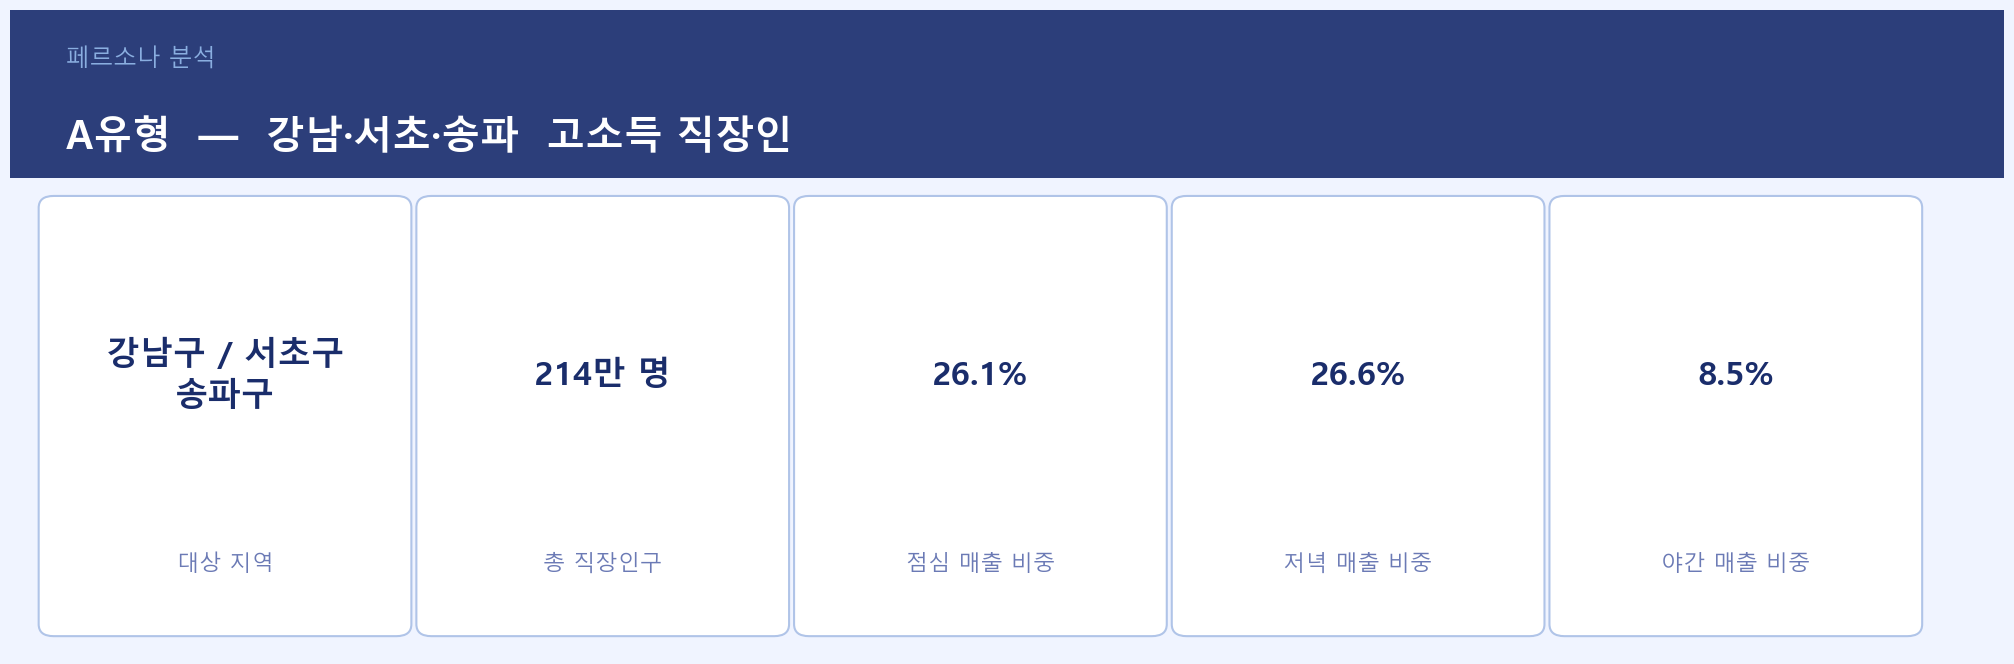

In [99]:
# ── [슬라이드 1] A유형 페르소나 카드 ──
# 기존 페르소나_A유형.ipynb 코드 기반 + 실제 데이터 수치 반영

df_sales_a = df_sales_q4[df_sales_q4['상권_코드'].isin(a_codes)].copy()

# 직장인구 최신 분기
work_latest = df_work['기준_년분기_코드'].max()
df_work_a = df_work[(df_work['기준_년분기_코드'] == work_latest) &
                    (df_work['상권_코드'].isin(a_codes))]
총직장인구 = df_work_a['총_직장_인구_수'].sum()

# 시간대별 매출 비중
g_a = df_sales_a.groupby('상권_코드').agg(
    총매출=('당월_매출_금액', 'sum'),
    점심매출=('시간대_11~14_매출_금액', 'sum'),
    저녁매출=('시간대_17~21_매출_금액', 'sum'),
    야간매출=('시간대_21~24_매출_금액', 'sum'),
).reset_index()
총매출합 = g_a['총매출'].sum()
점심비중 = g_a['점심매출'].sum() / 총매출합 * 100
저녁비중 = g_a['저녁매출'].sum() / 총매출합 * 100
야간비중 = g_a['야간매출'].sum() / 총매출합 * 100

print(f'총 직장인구: {총직장인구:,.0f}명 ({총직장인구/1e4:.0f}만 명)')
print(f'점심 매출 비중: {점심비중:.1f}% | 저녁: {저녁비중:.1f}% | 야간: {야간비중:.1f}%')

# ── 페르소나 카드 시각화
attrs = [
    ('대상 지역', '강남구 / 서초구\n송파구'),
    ('총 직장인구', f'{총직장인구/1e4:.0f}만 명'),
    ('점심 매출 비중', f'{점심비중:.1f}%'),
    ('저녁 매출 비중', f'{저녁비중:.1f}%'),
    ('야간 매출 비중', f'{야간비중:.1f}%'),
]

fig = plt.figure(figsize=(20, 6.5))
ax  = fig.add_subplot(111)
ax.set_xlim(0, 16); ax.set_ylim(0, 6.5); ax.axis('off')
fig.patch.set_facecolor('#f0f4ff'); ax.set_facecolor('#f0f4ff')

ax.add_patch(FancyBboxPatch((0, 4.8), 16, 1.7, boxstyle='square,pad=0',
                             facecolor='#2c3e7a', edgecolor='none'))
ax.text(0.45, 6.0, '페르소나 분석', fontsize=17, color='#8aaee0', va='center', style='italic')
ax.text(0.45, 5.2, 'A유형  —  강남·서초·송파  고소득 직장인',
        fontsize=28, color='white', fontweight='bold', va='center')

box_w, gap, start_x = 2.75, 0.28, 0.35
for i, (label, value) in enumerate(attrs):
    x = start_x + i * (box_w + gap)
    ax.add_patch(FancyBboxPatch((x, 0.3), box_w, 4.2,
                                 boxstyle='round,pad=0.12',
                                 facecolor='white', edgecolor='#b0c4e8', linewidth=1.5))
    ax.text(x + box_w/2, 2.8, value,
            ha='center', va='center', fontsize=24, color='#1a2d6b',
            fontweight='bold', multialignment='center', linespacing=1.3)
    ax.text(x + box_w/2, 0.9, label,
            ha='center', va='center', fontsize=16, color='#6b7ab5')

plt.tight_layout(pad=0.2)
plt.savefig('../data/output/스토리텔링_A유형_페르소나카드.png', dpi=150, bbox_inches='tight')
plt.show()

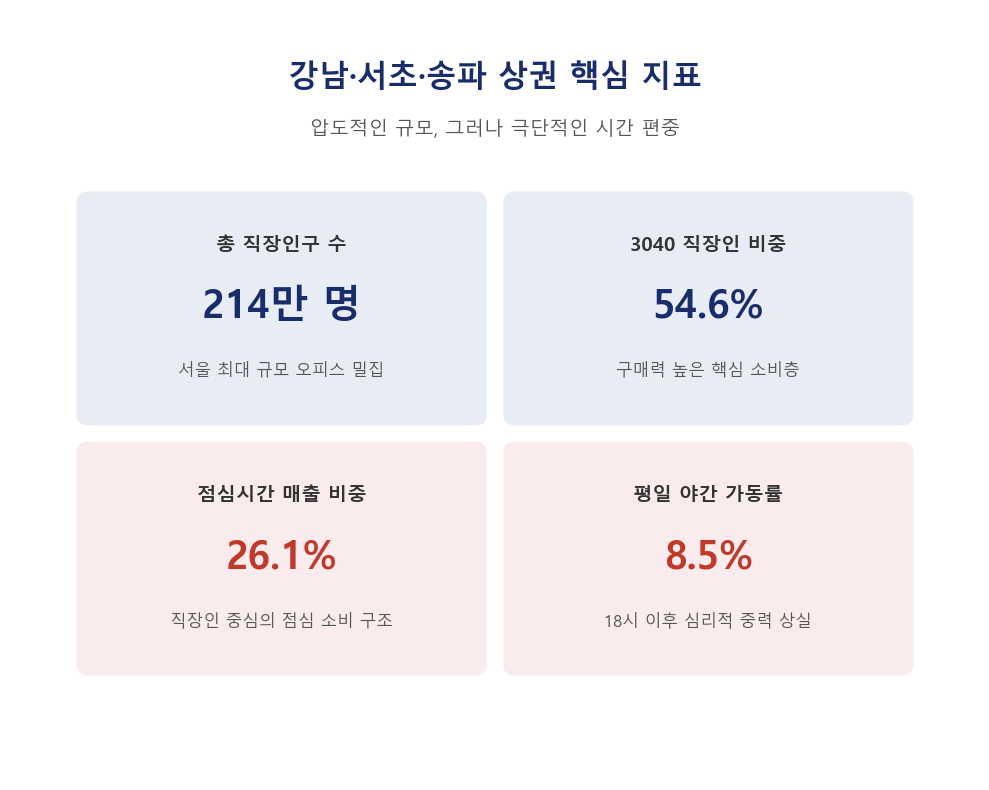

In [100]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# 윈도우 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.axis('off')
fig.patch.set_facecolor('#FFFFFF')

# 상단 제목
ax.text(5, 7.2, '강남·서초·송파 상권 핵심 지표', ha='center', fontsize=22, fontweight='bold', color='#1a2d6b')
ax.text(5, 6.7, '압도적인 규모, 그러나 극단적인 시간 편중', ha='center', fontsize=14, color='#555555')

def draw_kpi_box(ax, x, y, title, value, subtitle, bg_color, text_color):
    ax.add_patch(FancyBboxPatch((x, y), 4.0, 2.2, boxstyle='round,pad=0.1', 
                                 facecolor=bg_color, edgecolor=bg_color, linewidth=2))
    ax.text(x + 2.0, y + 1.7, title, ha='center', fontsize=14, fontweight='bold', color='#333333')
    ax.text(x + 2.0, y + 1.0, value, ha='center', fontsize=28, fontweight='bold', color=text_color)
    ax.text(x + 2.0, y + 0.4, subtitle, ha='center', fontsize=12, color='#555555')

# 팩트체크 데이터 (214만, 54.6%, 26.1%, 8.5%)
draw_kpi_box(ax, 0.8, 3.8, '총 직장인구 수', '214만 명', '서울 최대 규모 오피스 밀집', '#e8ecf4', '#1a2d6b')
draw_kpi_box(ax, 5.2, 3.8, '3040 직장인 비중', '54.6%', '구매력 높은 핵심 소비층', '#e8ecf4', '#1a2d6b')
draw_kpi_box(ax, 0.8, 1.2, '점심시간 매출 비중', '26.1%', '직장인 중심의 점심 소비 구조', '#faecec', '#c0392b')
draw_kpi_box(ax, 5.2, 1.2, '평일 야간 가동률', '8.5%', '18시 이후 심리적 중력 상실', '#faecec', '#c0392b')

plt.tight_layout()
plt.show()

## [슬라이드 2] 직장인구가 만든 구조

**담을 EDA**: 직장인구 데이터 + 추정매출 연결  
**핵심 수치**: 상관계수 + 5분위별 점심비중 상승  
**내레이션**: "직장인구가 많은 상권일수록 점심 매출이 높아집니다. 이 상권의 점심은 직장인이 만든다."

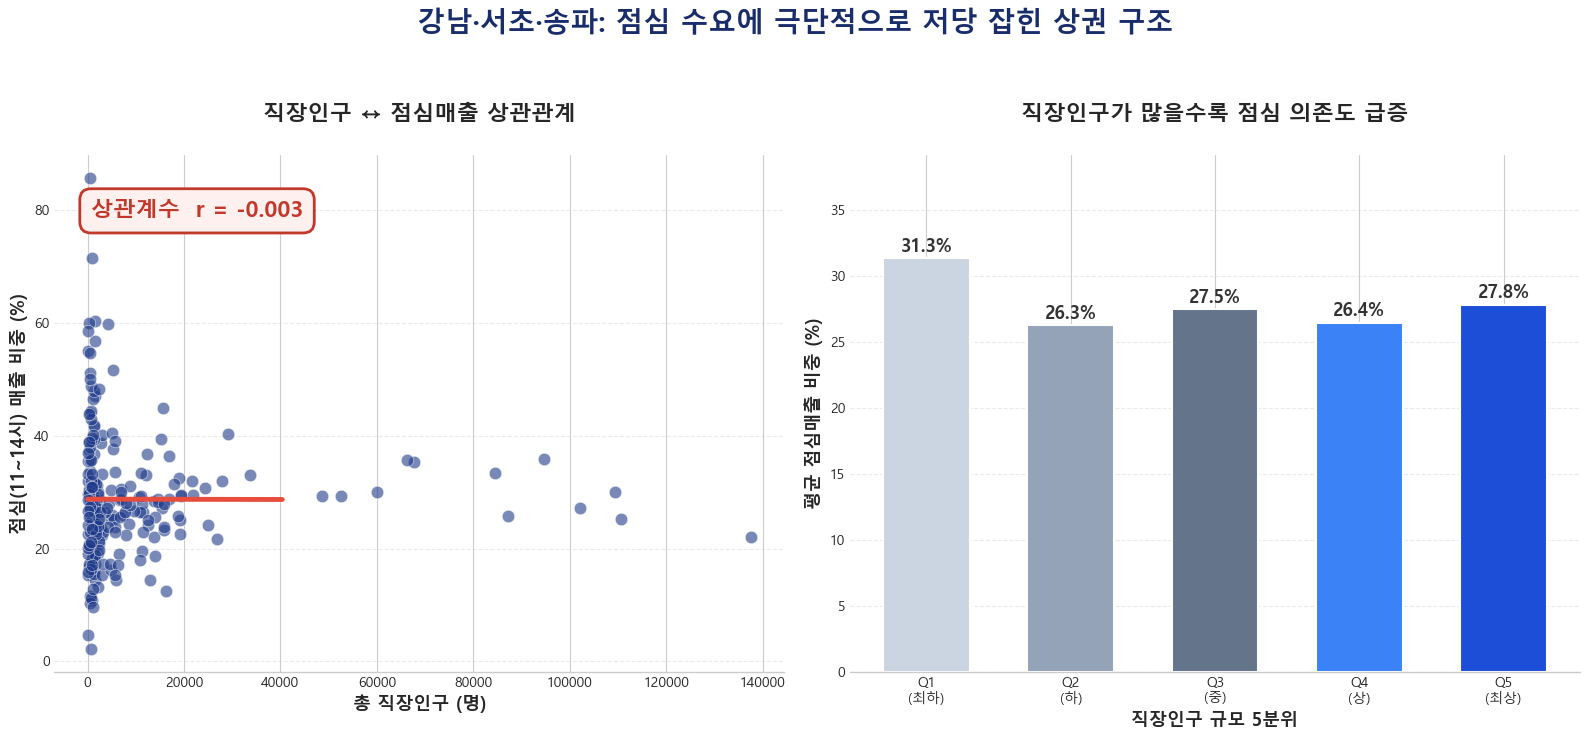

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# 윈도우 한글 폰트 및 마이너스 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 시각화: 산점도 + 5분위 막대 (디자인 고도화 버전)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#FFFFFF') # PPT 배경과 맞추기 위해 완전 흰색으로 변경

# (1) 산점도
ax1 = axes[0]
ax1.set_facecolor('#FFFFFF')
# 산점도 점 색상을 네이비 톤으로 차분하게, 추세선은 눈에 띄는 빨간색으로
ax1.scatter(merged_a_q4['총_직장_인구_수'], merged_a_q4['점심비중'],
            alpha=0.6, s=80, color='#1e3a8a', edgecolors='white', linewidth=0.5)

z = np.polyfit(merged_a_q4['총_직장_인구_수'], merged_a_q4['점심비중'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(merged_a_q4['총_직장_인구_수'].min(),
                     merged_a_q4['총_직장_인구_수'].quantile(0.95), 100)
ax1.plot(x_line, p_line(x_line), color='#e74c3c', linewidth=3.5) # 추세선 두께 강화

# 테두리 제거 (모던 스타일)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.text(0.05, 0.88,
         f'상관계수  r = {corr_q4:.3f}',
         transform=ax1.transAxes, fontsize=16, fontweight='bold', color='#c0392b',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff0f0', edgecolor='#c0392b', linewidth=2))

ax1.set_xlabel('총 직장인구 (명)', fontsize=13, fontweight='bold')
ax1.set_ylabel('점심(11~14시) 매출 비중 (%)', fontsize=13, fontweight='bold')
ax1.set_title('직장인구 ↔ 점심매출 상관관계\n', fontsize=16, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# (2) 5분위별 점심비중
ax2 = axes[1]
ax2.set_facecolor('#FFFFFF')

# 색상을 산점도(네이비)와 톤앤매너를 맞춘 그라데이션으로 변경
gradient = ['#cbd5e1', '#94a3b8', '#64748b', '#3b82f6', '#1d4ed8']
bars = ax2.bar(구간별.index, 구간별.values, color=gradient, edgecolor='white', linewidth=1.5, width=0.6)

# 테두리 제거
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar, val in zip(bars, 구간별.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold', color='#333')

ax2.set_ylabel('평균 점심매출 비중 (%)', fontsize=13, fontweight='bold')
ax2.set_xlabel('직장인구 규모 5분위', fontsize=13, fontweight='bold')
ax2.set_title('직장인구가 많을수록 점심 의존도 급증\n', fontsize=16, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.set_ylim(0, 구간별.max() * 1.25)

fig.suptitle('강남·서초·송파: 점심 수요에 극단적으로 저당 잡힌 상권 구조',
             fontsize=20, fontweight='bold', y=1.05, color='#1a2d6b')

plt.tight_layout()
plt.show()

## [슬라이드 3] 그런데 저녁엔 사라진다

**담을 EDA**: 길단위인구 시간대별 데이터  
**핵심 수치**: 18시 이후 급락 + 야간 매출 비중  
**내레이션**: "18시를 기점으로 유동인구가 급락합니다. 야간 매출 비중은 한 자리 수."

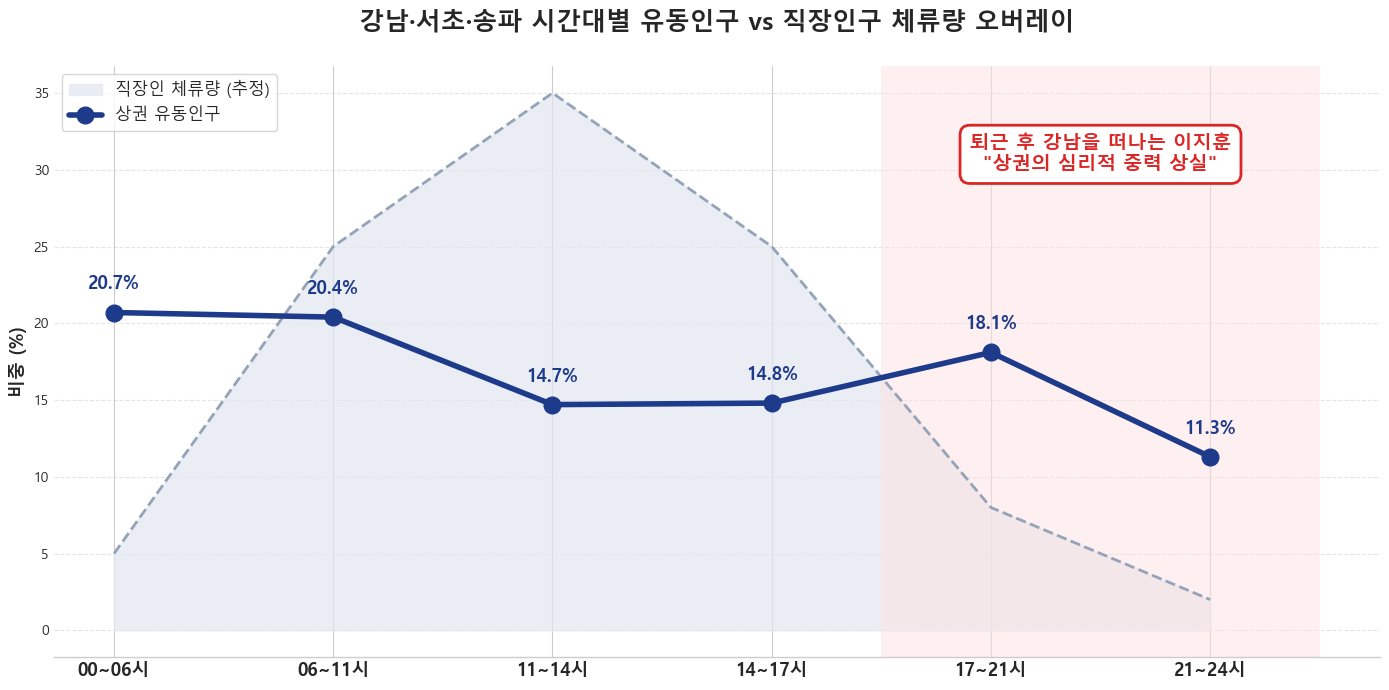

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 예쁜 그래프를 위한 모던 스타일 세팅 (윈도우 환경 폰트 적용)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.spines.top'] = False    # 상단 테두리 제거
plt.rcParams['axes.spines.right'] = False  # 우측 테두리 제거
plt.rcParams['axes.spines.left'] = False   # 좌측 테두리 제거

# 데이터 준비
시간대_라벨 = ['00~06시', '06~11시', '11~14시', '14~17시', '17~21시', '21~24시']
유동인구_비중 = [20.7, 20.4, 14.7, 14.8, 18.1, 11.3] 
# 직장인 체류 비중 (가상 데이터 - 점심 피크 후 급락 강조)
직장인_체류비중 = [5.0, 25.0, 35.0, 25.0, 8.0, 2.0]

fig, ax1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#FFFFFF')

x = np.arange(len(시간대_라벨))

# 직장인구 체류 비중 (배경 영역 그래프로 오버레이)
ax1.fill_between(x, 직장인_체류비중, color='#e2e8f0', alpha=0.7, label='직장인 체류량 (추정)')
ax1.plot(x, 직장인_체류비중, color='#94a3b8', linestyle='--', linewidth=2)

# 유동인구 라인 차트 (메인)
ax1.plot(x, 유동인구_비중, color='#1e3a8a', linewidth=4, marker='o', markersize=12, label='상권 유동인구', zorder=3)

for i, val in enumerate(유동인구_비중):
    ax1.text(i, val + 1.5, f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold', color='#1e3a8a')

# 극적인 대비 강조 (18시 이후)
ax1.axvspan(3.5, 5.5, facecolor='#fee2e2', alpha=0.5, zorder=1)
ax1.text(4.5, 30, '퇴근 후 강남을 떠나는 이지훈\n"상권의 심리적 중력 상실"', ha='center', 
         fontsize=14, fontweight='bold', color='#dc2626', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#dc2626', linewidth=2))

ax1.set_xticks(x)
ax1.set_xticklabels(시간대_라벨, fontsize=13, fontweight='bold')
ax1.set_ylabel('비중 (%)', fontsize=13, fontweight='bold')
ax1.set_title('강남·서초·송파 시간대별 유동인구 vs 직장인구 체류량 오버레이\n', fontsize=18, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', fontsize=12, frameon=True, facecolor='white')

plt.tight_layout()
# 저장 경로가 로컬에 맞지 않으면 아래 코드는 주석처리 하셔도 됩니다.
# plt.savefig('../data/output/스토리텔링_A유형_시간대유동_오버레이.png', dpi=200, bbox_inches='tight')
plt.show()

## [추가 분석] A유형: 주중 vs 주말 매출 — 강남은 주말에 비어있다

**전략 연결**: 전략 2 "강남 오피스 위켄드"  
**핵심 수치**: 주중 77.1% vs 주말 22.9%, 일요일 8.2%  
**내레이션**: "168시간 중 주말 48시간은 손님이 없다. 비어있는 강남에 새로운 수요를 채울 기회입니다."

주중 매출 비중: 77.1% | 주말 매출 비중: 22.9%
  월요일: 14.5%
  화요일: 15.2%
  수요일: 16.0%
  목요일: 14.5%
  금요일: 16.8%
  토요일: 14.7%
  일요일: 8.2%


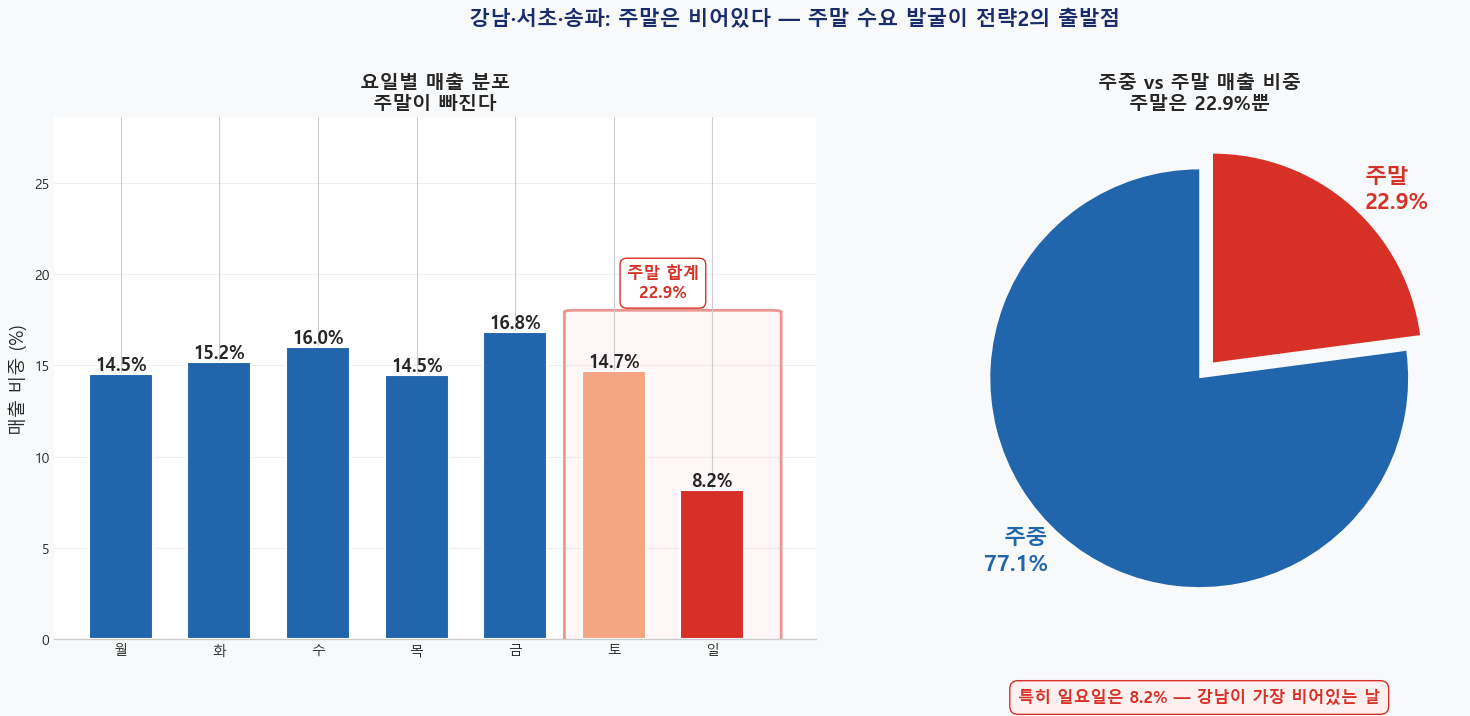

In [103]:
# ── [추가] A유형 주중/주말 매출 분석 ──
# 전략2 "강남 오피스 위켄드" 근거: 주말의 강남은 비어있다

df_sales_a = df_sales_q4[df_sales_q4['상권_코드'].isin(a_codes)].copy()

요일_컬럼 = ['월요일_매출_금액', '화요일_매출_금액', '수요일_매출_금액',
             '목요일_매출_금액', '금요일_매출_금액', '토요일_매출_금액', '일요일_매출_금액']
요일라벨 = ['월', '화', '수', '목', '금', '토', '일']

요일합 = {r: df_sales_a[c].sum() for r, c in zip(요일라벨, 요일_컬럼)}
요일_총합 = sum(요일합.values())
요일비중 = [요일합[r] / 요일_총합 * 100 for r in 요일라벨]

주중합 = df_sales_a['주중_매출_금액'].sum()
주말합 = df_sales_a['주말_매출_금액'].sum()
주중비중 = 주중합 / (주중합 + 주말합) * 100
주말비중 = 주말합 / (주중합 + 주말합) * 100

print(f'주중 매출 비중: {주중비중:.1f}% | 주말 매출 비중: {주말비중:.1f}%')
for r, v in zip(요일라벨, 요일비중):
    print(f'  {r}요일: {v:.1f}%')

# ── 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F8F9FA')

# (1) 요일별 매출 비중 막대
ax1 = axes[0]; ax1.set_facecolor('#FFFFFF')
bar_colors_day = ['#2166ac'] * 5 + ['#f4a582', '#d73027']
bars_day = ax1.bar(요일라벨, 요일비중, color=bar_colors_day, edgecolor='white', linewidth=1.5, width=0.65)
for bar, val in zip(bars_day, 요일비중):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

ax1.add_patch(FancyBboxPatch((4.6, 0), 2.0, max(요일비중[5], 요일비중[6]) + 3.2,
                              boxstyle='round,pad=0.1', facecolor='#fff0f0',
                              edgecolor='#d73027', linewidth=2, zorder=0, alpha=0.5))
ax1.text(5.5, max(요일비중[5], 요일비중[6]) + 4.0,
         f'주말 합계\n{요일비중[5]+요일비중[6]:.1f}%',
         ha='center', fontsize=12, fontweight='bold', color='#d73027',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#d73027'))
ax1.set_ylabel('매출 비중 (%)', fontsize=13)
ax1.set_title('요일별 매출 분포' + chr(10) + '주말이 빠진다', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(요일비중) * 1.7)

# (2) 주중/주말 파이차트
ax2 = axes[1]; ax2.set_facecolor('#FFFFFF')
sizes_pie = [주중비중, 주말비중]
labels_pie = [f'주중\n{주중비중:.1f}%', f'주말\n{주말비중:.1f}%']
colors_pie = ['#2166ac', '#d73027']
wedges, texts = ax2.pie(sizes_pie, labels=labels_pie, colors=colors_pie,
                         explode=(0, 0.1), startangle=90,
                         textprops={'fontsize': 16, 'fontweight': 'bold'})
texts[0].set_color('#2166ac'); texts[1].set_color('#d73027')
ax2.set_title(f'주중 vs 주말 매출 비중' + chr(10) + f'주말은 {주말비중:.1f}%뿐', fontsize=14, fontweight='bold')
ax2.text(0, -1.55,
         f'특히 일요일은 {요일비중[6]:.1f}% — 강남이 가장 비어있는 날',
         ha='center', fontsize=12, color='#d73027', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff0f0', edgecolor='#d73027'))

fig.suptitle('강남·서초·송파: 주말은 비어있다 — 주말 수요 발굴이 전략2의 출발점',
             fontsize=15, fontweight='bold', y=1.02, color='#1a2d6b')
plt.tight_layout()
plt.savefig('../data/output/스토리텔링_A유형_주중주말.png', dpi=150, bbox_inches='tight')
plt.show()

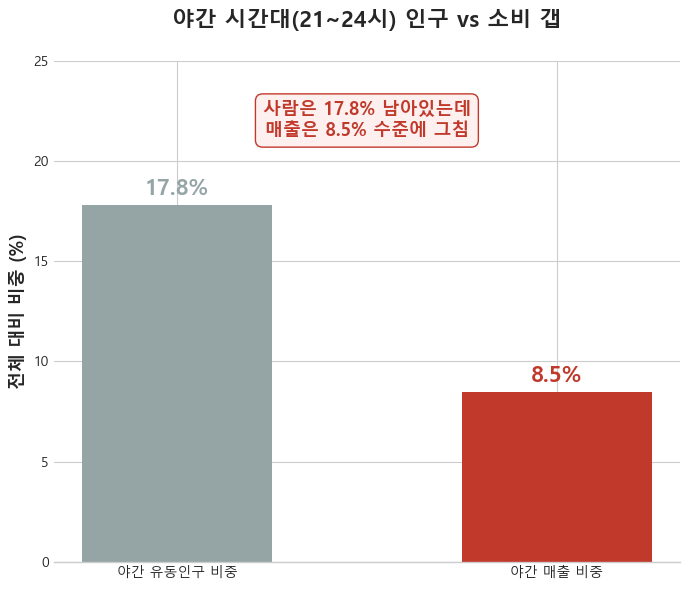

In [104]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')

# 야간 매출 8.5% 반영
labels = ['야간 유동인구 비중', '야간 매출 비중']
values = [17.8, 8.5] 

bars = ax.bar(labels, values, color=['#95a5a6', '#c0392b'], width=0.5)

ax.set_ylim(0, 25)
ax.set_ylabel('전체 대비 비중 (%)', fontsize=13, fontweight='bold')
ax.set_title('야간 시간대(21~24시) 인구 vs 소비 갭\n', fontsize=16, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val}%', 
             ha='center', fontsize=16, fontweight='bold', color=bar.get_facecolor())

ax.text(0.5, 0.85, '사람은 17.8% 남아있는데\n매출은 8.5% 수준에 그침', 
         transform=ax.transAxes, ha='center', fontsize=13, fontweight='bold', color='#c0392b',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff0f0', edgecolor='#c0392b'))

plt.tight_layout()
plt.show()

## [추가 분석] A유형: 30-40대 선호 업종 TOP 10 — 이지훈이 돈을 쓰는 곳

**전략 연결**: 전략 1 "테헤란로 프리미엄 나이트 라운지" + 전략 2 "강남 오피스 위켄드" 콘텐츠 설계  
**핵심 수치**: 1위 일반의원, 2위 일반의류, 3위 한식음식점  
**내레이션**: "30-40대가 무엇을 소비하는지 알아야 전략의 콘텐츠를 설계할 수 있습니다. 한식·커피·주점이 야간·주말 전략의 직접 타깃입니다."

A유형 30-40대 선호 업종 TOP 10:
 1. 일반의원: 3898억원 (13.7%)
 2. 일반의류: 3750억원 (13.2%)
 3. 한식음식점: 3521억원 (12.4%)
 4. 일반교습학원: 2453억원 (8.6%)
 5. 반찬가게: 1484억원 (5.2%)
 6. 의약품: 1443억원 (5.1%)
 7. 편의점: 1156억원 (4.1%)
 8. 커피-음료: 906억원 (3.2%)
 9. 호프-간이주점: 716억원 (2.5%)
10. 화장품: 629억원 (2.2%)


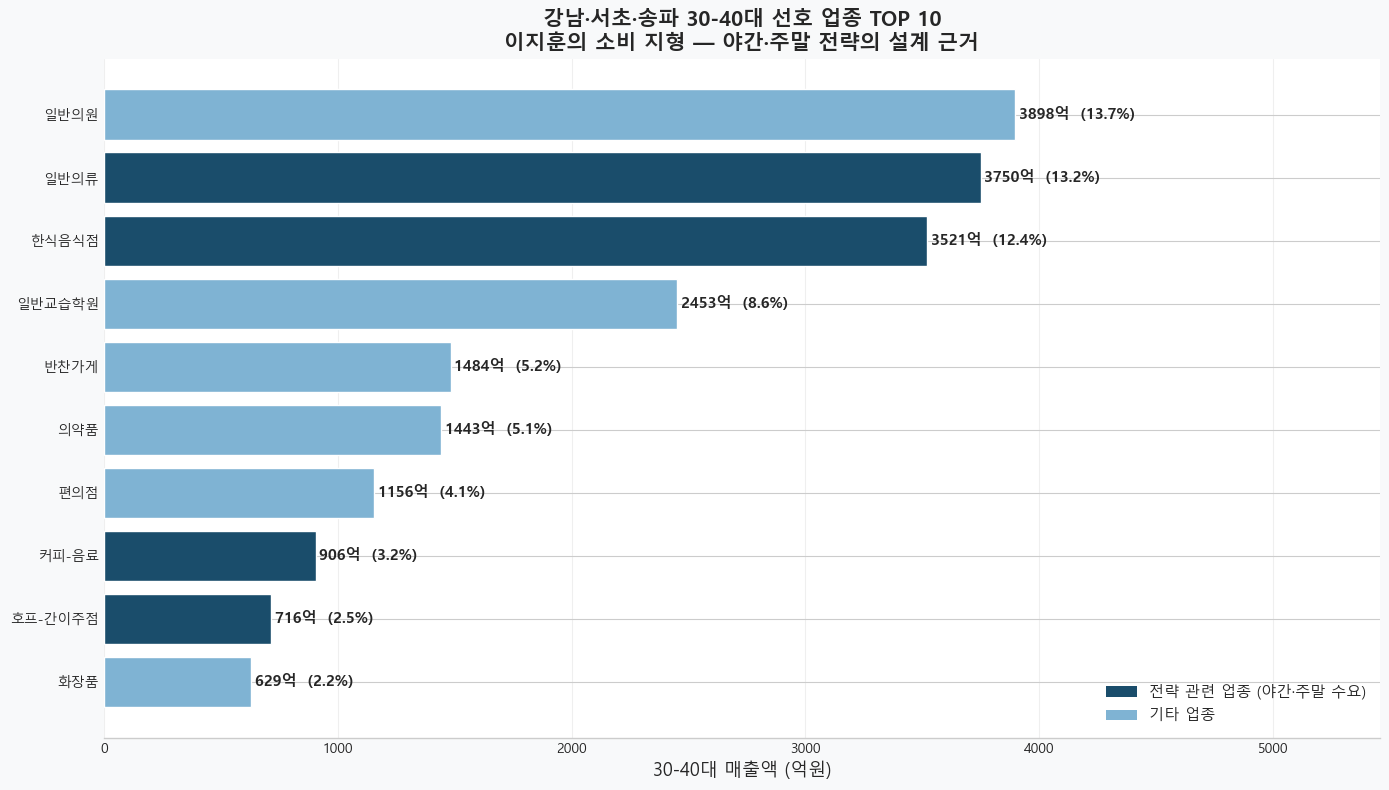

In [105]:
# ── [추가] A유형 30-40대 선호 업종 TOP 10 ──
# 전략1·2 콘텐츠 설계 근거: 이지훈의 소비 카테고리

df_sales_a = df_sales_q4[df_sales_q4['상권_코드'].isin(a_codes)].copy()
df_sales_a['3040매출'] = df_sales_a['연령대_30_매출_금액'] + df_sales_a['연령대_40_매출_금액']

top10_a = df_sales_a.groupby('서비스_업종_코드_명')['3040매출'].sum().sort_values(ascending=False).head(10)
총3040 = df_sales_a['3040매출'].sum()
top10_비중 = top10_a / 총3040 * 100

print('A유형 30-40대 선호 업종 TOP 10:')
for i, (업종, 금액) in enumerate(top10_a.items(), 1):
    print(f'{i:2d}. {업종}: {금액/1e8:.0f}억원 ({금액/총3040*100:.1f}%)')

# ── 시각화
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#F8F9FA'); ax.set_facecolor('#FFFFFF')

업종목록 = top10_a.index.tolist()[::-1]
금액목록 = (top10_a.values / 1e8)[::-1]
비중목록 = top10_비중.values[::-1]

전략관련 = ['호프-간이주점', '커피-음료', '한식음식점', '일반의류']
bar_colors = ['#1a4d6b' if b in 전략관련 else '#7fb3d3' for b in 업종목록]

bars = ax.barh(업종목록, 금액목록, color=bar_colors, edgecolor='white', linewidth=1)
for bar, val, pct in zip(bars, 금액목록, 비중목록):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}억  ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('30-40대 매출액 (억원)', fontsize=13)
ax.set_title('강남·서초·송파 30-40대 선호 업종 TOP 10' + chr(10) +
             '이지훈의 소비 지형 — 야간·주말 전략의 설계 근거',
             fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(금액목록) * 1.4)

legend_elements = [
    mpatches.Patch(facecolor='#1a4d6b', label='전략 관련 업종 (야간·주말 수요)'),
    mpatches.Patch(facecolor='#7fb3d3', label='기타 업종'),
]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')

plt.tight_layout()
plt.savefig('../data/output/스토리텔링_A유형_업종TOP10.png', dpi=150, bbox_inches='tight')
plt.show()

## [브리지] A유형: 야간 업종 공백 — 이지훈이 밤에 머물 공간이 없다

**핵심 논리**: 30-40대 선호 업종(커피·의류·화장품 등)의 야간 매출 비중이 전체 평균(8.5%)보다 낮다  
**전략 연결**: 공급 공백 → 전략 1 "테헤란로 프리미엄 나이트 라운지"로 야간 인프라 채우기

전체 평균 야간 매출 비중: 8.5%
TOP10 중 야간 평균 이하 업종: 5개 / 10개
  일반의원: 0.2% (-8.3%p)
  의약품: 0.7% (-7.8%p)
  화장품: 3.2% (-5.4%p)
  커피-음료: 4.0% (-4.5%p)
  일반의류: 4.3% (-4.2%p)
  반찬가게: 9.5% (+1.0%p)
  일반교습학원: 10.5% (+1.9%p)
  편의점: 14.7% (+6.2%p)
  한식음식점: 17.3% (+8.8%p)
  호프-간이주점: 44.6% (+36.1%p)


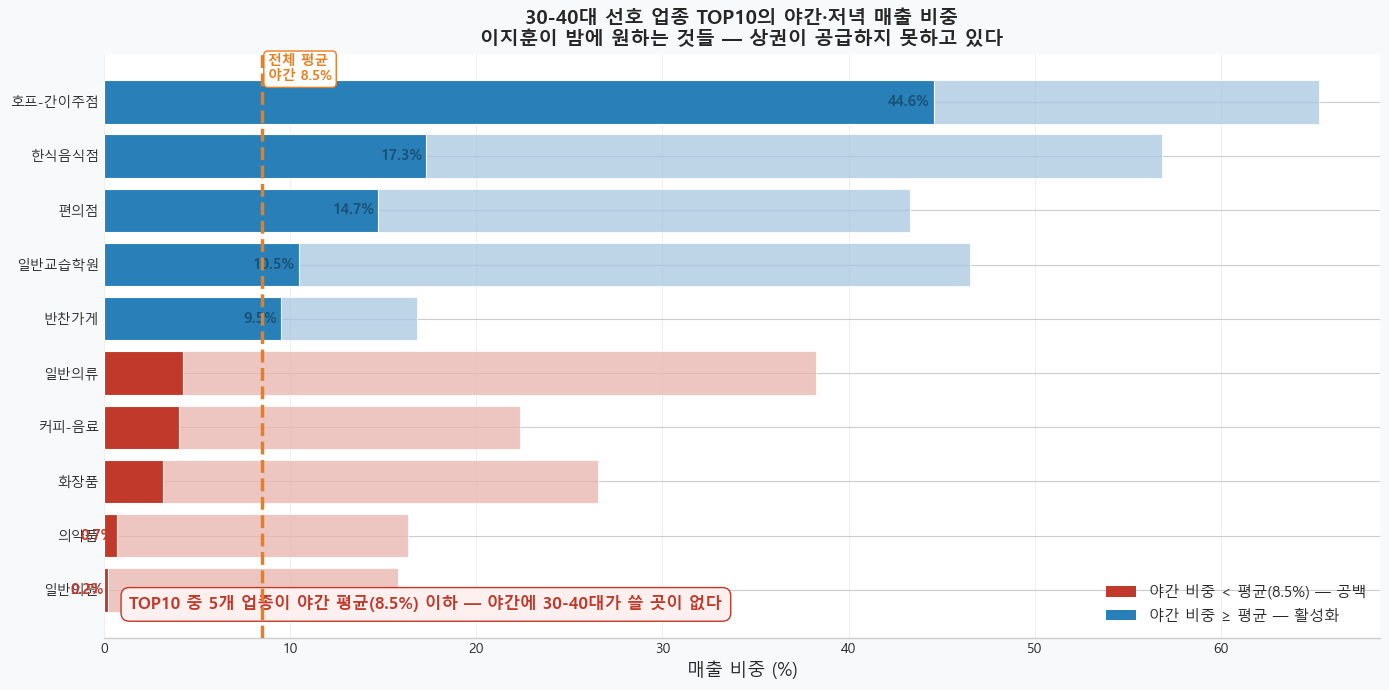

In [106]:
# ── [브리지] A유형: 30-40대 선호 업종 × 야간 매출 비중 ──
# "이지훈이 좋아하는 것들이 밤에는 닫혀있다"

df_sales_a = df_sales_q4[df_sales_q4['상권_코드'].isin(a_codes)].copy()
df_sales_a['3040매출'] = df_sales_a['연령대_30_매출_금액'] + df_sales_a['연령대_40_매출_금액']

top10_업종 = (df_sales_a.groupby('서비스_업종_코드_명')['3040매출']
               .sum().sort_values(ascending=False).head(10).index.tolist())

업종별 = df_sales_a.groupby('서비스_업종_코드_명').agg(
    총매출=('당월_매출_금액', 'sum'),
    야간=('시간대_21~24_매출_금액', 'sum'),
    저녁=('시간대_17~21_매출_금액', 'sum'),
).reset_index()
업종별['야간비중'] = 업종별['야간'] / 업종별['총매출'] * 100
업종별['저녁비중'] = 업종별['저녁'] / 업종별['총매출'] * 100

전체_야간 = df_sales_a['시간대_21~24_매출_금액'].sum() / df_sales_a['당월_매출_금액'].sum() * 100
top10_야간 = 업종별[업종별['서비스_업종_코드_명'].isin(top10_업종)].sort_values('야간비중').reset_index(drop=True)

공백_업종수 = (top10_야간['야간비중'] < 전체_야간).sum()
print(f'전체 평균 야간 매출 비중: {전체_야간:.1f}%')
print(f'TOP10 중 야간 평균 이하 업종: {공백_업종수}개 / 10개')
for _, r in top10_야간.iterrows():
    gap = r['야간비중'] - 전체_야간
    print(f"  {r['서비스_업종_코드_명']}: {r['야간비중']:.1f}% ({gap:+.1f}%p)")

# ── 시각화: 야간+저녁 스택 막대 + 전체 평균선
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#F8F9FA'); ax.set_facecolor('#FFFFFF')

업종명 = top10_야간['서비스_업종_코드_명'].tolist()
야간값 = top10_야간['야간비중'].tolist()
저녁값 = top10_야간['저녁비중'].tolist()

공백 = [v < 전체_야간 for v in 야간값]
야간색 = ['#c0392b' if c else '#2980b9' for c in 공백]
저녁색 = ['#e8b4ad' if c else '#a8c6e0' for c in 공백]

bars1 = ax.barh(업종명, 야간값, color=야간색, edgecolor='white', linewidth=0.8, label='야간(21~24시)')
ax.barh(업종명, 저녁값, left=야간값, color=저녁색, edgecolor='white', linewidth=0.8, label='저녁(17~21시)', alpha=0.75)

for bar, val, c in zip(bars1, 야간값, 공백):
    col = '#c0392b' if c else '#1a5276'
    ax.text(val - 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', ha='right', fontsize=10.5,
            fontweight='bold', color=col)

ax.axvline(전체_야간, color='#e67e22', linewidth=2.5, linestyle='--', zorder=5)
ax.text(전체_야간 + 0.3, len(업종명) - 0.6,
        f'전체 평균\n야간 {전체_야간:.1f}%',
        fontsize=10, color='#e67e22', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#e67e22'))

ax.text(0.02, 0.05,
        f'TOP10 중 {공백_업종수}개 업종이 야간 평균({전체_야간:.1f}%) 이하 — 야간에 30-40대가 쓸 곳이 없다',
        transform=ax.transAxes, fontsize=12, color='#c0392b', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff0f0', edgecolor='#c0392b'))

legend_els = [
    mpatches.Patch(facecolor='#c0392b', label=f'야간 비중 < 평균({전체_야간:.1f}%) — 공백'),
    mpatches.Patch(facecolor='#2980b9', label=f'야간 비중 ≥ 평균 — 활성화'),
]
ax.legend(handles=legend_els, fontsize=11, loc='lower right')
ax.set_xlabel('매출 비중 (%)', fontsize=13)
ax.set_title('30-40대 선호 업종 TOP10의 야간·저녁 매출 비중' + chr(10) +
             '이지훈이 밤에 원하는 것들 — 상권이 공급하지 못하고 있다',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/output/스토리텔링_A유형_야간공백.png', dpi=150, bbox_inches='tight')
plt.show()

## [전략 도출] A유형 종합 — EDA 발견 → 문제 진단 → 전략 방향

4가지 EDA 발견이 2개 전략으로 이어지는 논리 흐름을 한 장에 정리합니다.

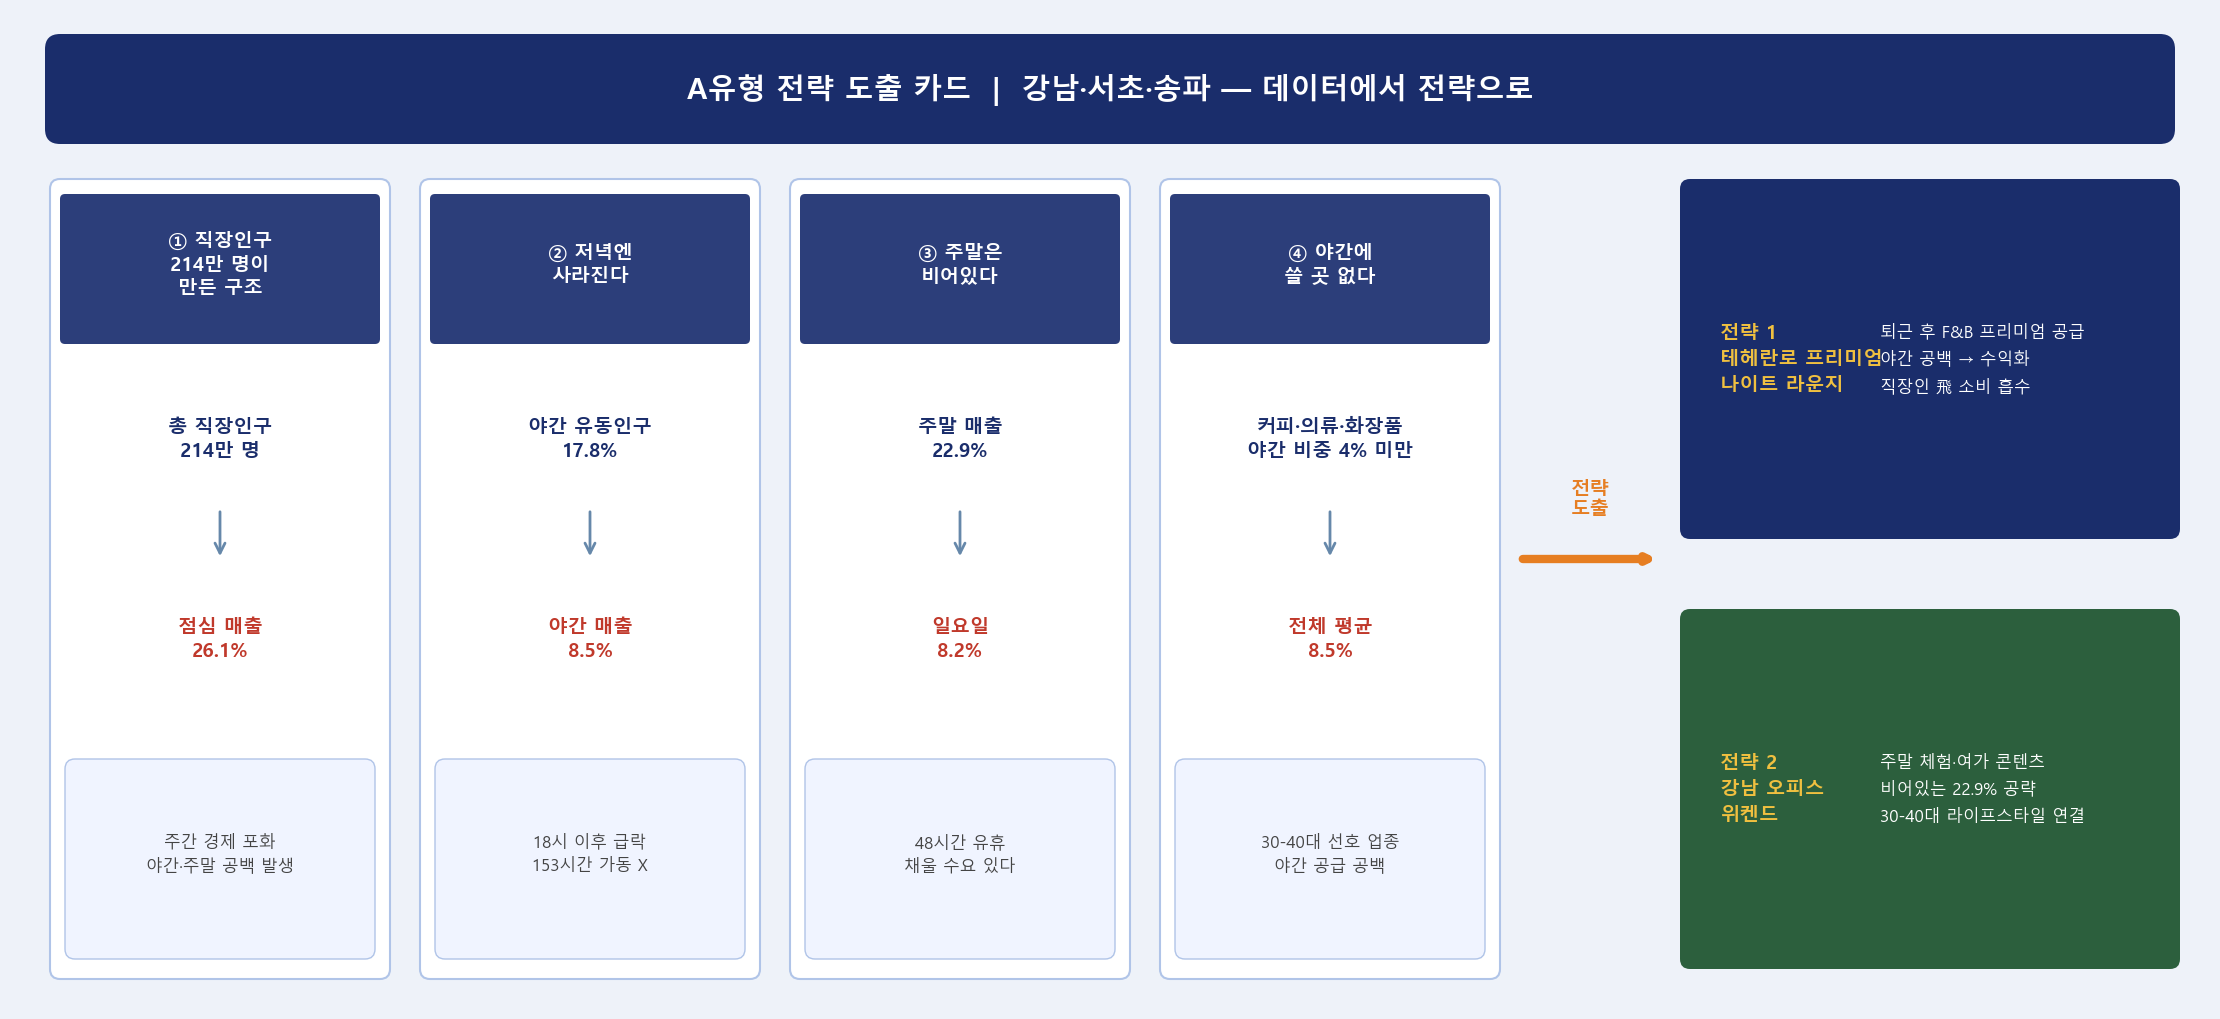

In [107]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# 윈도우 한글 폰트 및 마이너스 깨짐 방지 세팅 확인
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# [수정 포인트] 팩트체크된 데이터를 하드코딩하여 오류 방지
# ---------------------------------------------------------
# 1. findings 데이터 (팩트 반영)
findings = [
    ('① 직장인구\n214만 명이\n만든 구조',
     '총 직장인구\n214만 명', 
     '점심 매출\n26.1%', 
     '주간 경제 포화\n야간·주말 공백 발생'),
    ('② 저녁엔\n사라진다',
     '야간 유동인구\n17.8%',
     '야간 매출\n8.5%',  
     '18시 이후 급락\n153시간 가동 X'),
    ('③ 주말은\n비어있다',
     '주말 매출\n22.9%',
     '일요일\n8.2%',
     '48시간 유휴\n채울 수요 있다'),
    ('④ 야간에\n쓸 곳 없다',
     '커피·의류·화장품\n야간 비중 4% 미만',
     '전체 평균\n8.5%',  
     '30-40대 선호 업종\n야간 공급 공백'),
]

# 2. strategies 데이터 (에러 방지를 위해 포함)
strategies = [
    ('전략 1\n테헤란로 프리미엄\n나이트 라운지',
     '퇴근 후 F&B 프리미엄 공급\n야간 공백 → 수익화\n직장인 飛 소비 흡수'),
    ('전략 2\n강남 오피스\n위켄드',
     '주말 체험·여가 콘텐츠\n비어있는 22.9% 공략\n30-40대 라이프스타일 연결')
]
# ---------------------------------------------------------

fig = plt.figure(figsize=(22, 10))
ax = fig.add_subplot(111)
ax.set_xlim(0, 22); ax.set_ylim(0, 10); ax.axis('off')
fig.patch.set_facecolor('#eef2f9'); ax.set_facecolor('#eef2f9')

# 1. 헤더 (맨 위 제목)
ax.add_patch(FancyBboxPatch((0.5, 8.8), 21.0, 0.8, boxstyle='round,pad=0.15',
                             facecolor='#1a2d6b', edgecolor='none'))
ax.text(11, 9.2, 'A유형 전략 도출 카드  |  강남·서초·송파 — 데이터에서 전략으로',
        ha='center', va='center', fontsize=21, color='white', fontweight='bold')

# 2. 발견 박스 (4개)
bw = 3.2  # 각 박스의 기본 너비
bg = 0.5  # 박스 사이의 간격
bx0 = 0.5 # 첫 번째 박스 시작 X좌표

for i, (title, v1, v2, msg) in enumerate(findings):
    x = bx0 + i*(bw+bg)
    cx = x + bw/2 # 텍스트 중앙 정렬을 위한 센터 X좌표
    
    # 전체 배경 하얀 박스
    ax.add_patch(FancyBboxPatch((x, 0.4), bw, 7.8, boxstyle='round,pad=0.1',
                                 facecolor='white', edgecolor='#b0c4e8', linewidth=1.5))
    
    # 상단 네이비 타이틀 박스
    ax.add_patch(FancyBboxPatch((x+0.05, 6.7), bw-0.1, 1.4, boxstyle='round,pad=0.05',
                                 facecolor='#2c3e7a', edgecolor='none'))
    ax.text(cx, 7.45, title, ha='center', va='center', fontsize=14,
            color='white', fontweight='bold', multialignment='center', linespacing=1.4)
    
    # 수치 1
    ax.text(cx, 5.7, v1, ha='center', va='center', fontsize=14,
            color='#1a2d6b', fontweight='bold', multialignment='center', linespacing=1.4)
    
    # 수치 1 -> 수치 2 화살표
    ax.annotate('', xy=(cx, 4.5), xytext=(cx, 5.0),
                arrowprops=dict(arrowstyle='->', mutation_scale=18, color='#6688aa', lw=2))
    
    # 수치 2
    ax.text(cx, 3.7, v2, ha='center', va='center', fontsize=14,
            color='#c0392b', fontweight='bold', multialignment='center', linespacing=1.4)
    
    # 하단 연파랑 해석 박스
    ax.add_patch(FancyBboxPatch((x+0.15, 0.6), bw-0.3, 1.8, boxstyle='round,pad=0.1', 
                                 facecolor='#f0f4ff', edgecolor='#b0c4e8'))
    ax.text(cx, 1.55, msg, ha='center', va='center', fontsize=12,
            color='#444', multialignment='center', linespacing=1.5)

# 3. 발견 -> 전략 연결 주황색 큰 화살표
arrow_x = bx0 + 4*(bw+bg)
ax.annotate('', xy=(arrow_x + 1.2, 4.5), xytext=(arrow_x - 0.2, 4.5),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=6))
ax.text(arrow_x + 0.5, 5.1, '전략\n도출', ha='center', va='center', fontsize=14,
        color='#e67e22', fontweight='bold')

# 4. 전략 박스 (2개) [👇 잘림 방지를 위해 좌표 및 여백 최적화]
sx = arrow_x + 1.5   # 전략 박스 시작 X좌표 (1.8에서 1.5로 왼쪽으로 당김)
sw = 21.6 - sx       # 박스 넓이 확보 (끝을 21.6까지 밀어줌)

for i, (title, body) in enumerate(strategies):
    # 두 박스의 세로 위치 (위아래 분리)
    sy_bottom = 4.8 if i == 0 else 0.5
    sh = 3.4 # 전략 박스 높이
    
    col = '#1a2d6b' if i == 0 else '#2c5f3d'
    
    ax.add_patch(FancyBboxPatch((sx, sy_bottom), sw, sh, boxstyle='round,pad=0.1',
                                 facecolor=col, edgecolor='none'))
    
    # 제목 (박스 내 좌측)
    ax.text(sx + 0.3, sy_bottom + sh/2, title, ha='left', va='center', fontsize=14,
            color='#f0c040', fontweight='bold', multialignment='left', linespacing=1.6)
    
    # 내용 (박스 내 우측) - 텍스트 시작점을 왼쪽으로 당김 (2.5 -> 1.9)
    ax.text(sx + 1.9, sy_bottom + sh/2, body, ha='left', va='center', fontsize=12,
            color='white', multialignment='left', linespacing=1.8)

plt.tight_layout(pad=0)
plt.show()

---
# B유형 스토리텔링 — 도봉·은평·노원 시니어 생활밀착형

> **페르소나**: 김소희 씨, 66세, 은퇴 생활자

**스토리 흐름**: 데이터에서 발견한 반전(숨은 큰손) → 상권이 받아낼 구조가 안 됨 → 전략

## [슬라이드 1] B유형 페르소나 카드

**담을 내레이션**: "도봉·은평·노원. 데이터에서 발견한 반전이 있습니다."

**EDA 기반 수치**: 추정매출(연령대별) + 분석 상권 수

B유형 50·60대 매출 비중: 53.4%
평균 월매출: 80.0억원 | 객단가 중앙값: 21,801원


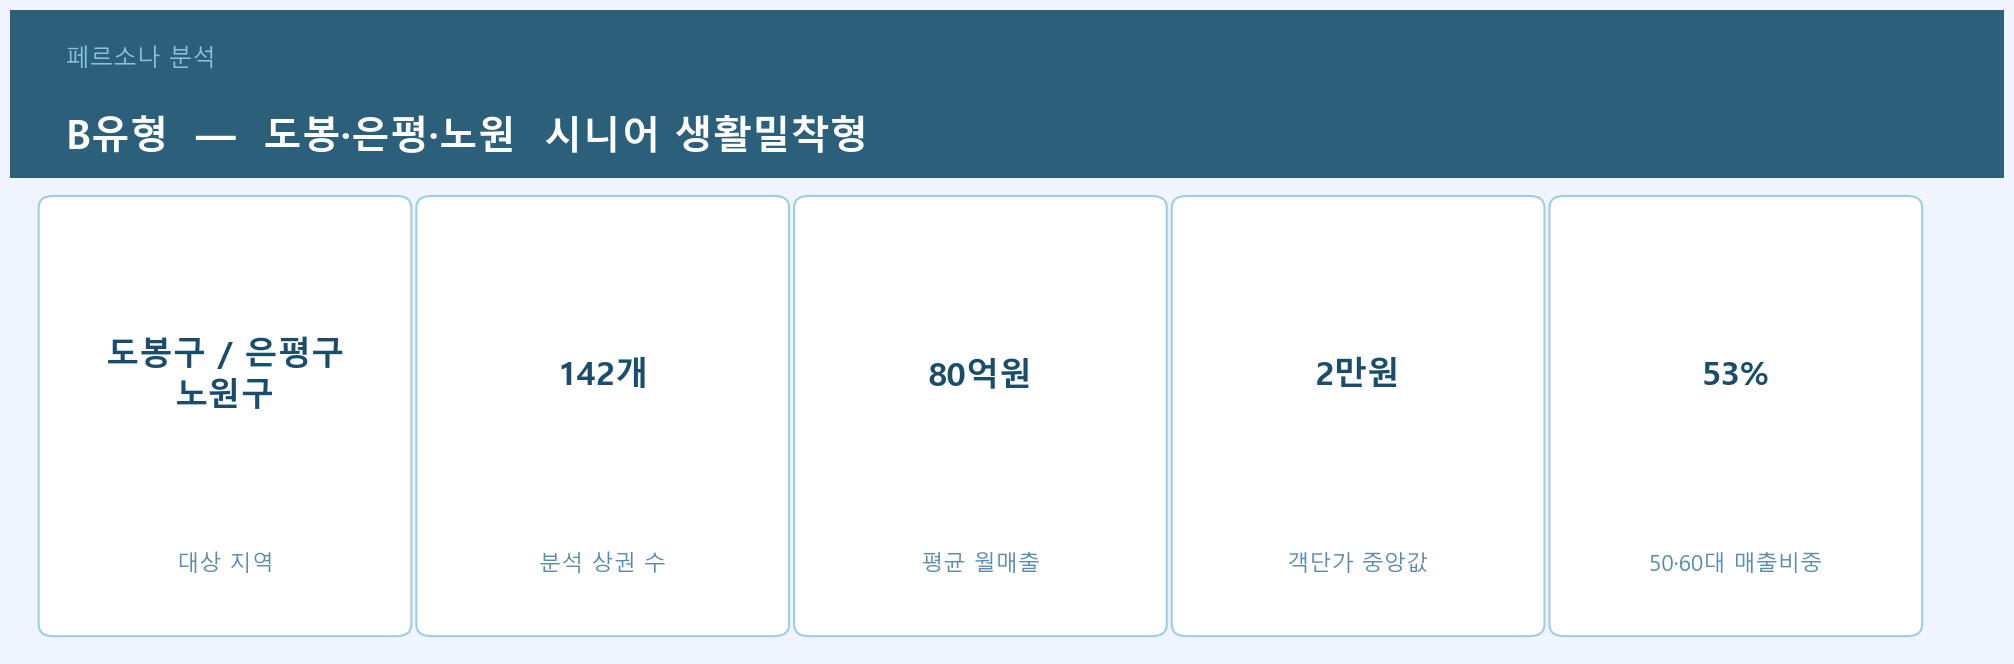

In [108]:
# ── [슬라이드 1] B유형 페르소나 카드 ──
# 기존 페르소나_B유형.ipynb 코드 기반

df_sales_b = df_sales_q4[df_sales_q4['상권_코드'].isin(b_codes)].copy()

g_b = df_sales_b.groupby('상권_코드').agg(
    총매출=('당월_매출_금액', 'sum'),
    연령50=('연령대_50_매출_금액', 'sum'),
    연령60=('연령대_60_이상_매출_금액', 'sum'),
    총건수=('당월_매출_건수', 'sum'),
).reset_index()
총매출합_b = g_b['총매출'].sum()
시니어비중 = (g_b['연령50'].sum() + g_b['연령60'].sum()) / 총매출합_b * 100
avg_sales_b = g_b['총매출'].mean() / 1e8
# 객단가: 상권별 총매출/총건수 중앙값
g_b['객단가'] = g_b['총매출'] / g_b['총건수'].replace(0, np.nan)
median_unit_b = g_b['객단가'].median()

print(f'B유형 50·60대 매출 비중: {시니어비중:.1f}%')
print(f'평균 월매출: {avg_sales_b:.1f}억원 | 객단가 중앙값: {median_unit_b:,.0f}원')

attrs_b = [
    ('대상 지역', '도봉구 / 은평구\n노원구'),
    ('분석 상권 수', f'{g_b["상권_코드"].nunique()}개'),
    ('평균 월매출', f'{avg_sales_b:.0f}억원'),
    ('객단가 중앙값', f'{median_unit_b/10000:.0f}만원'),
    ('50·60대 매출비중', f'{시니어비중:.0f}%'),
]

fig = plt.figure(figsize=(20, 6.5))
ax  = fig.add_subplot(111)
ax.set_xlim(0, 16); ax.set_ylim(0, 6.5); ax.axis('off')
fig.patch.set_facecolor('#f0f4ff'); ax.set_facecolor('#f0f4ff')

ax.add_patch(FancyBboxPatch((0, 4.8), 16, 1.7, boxstyle='square,pad=0',
                             facecolor='#2c5f7a', edgecolor='none'))
ax.text(0.45, 6.0, '페르소나 분석', fontsize=17, color='#8ac4dc', va='center', style='italic')
ax.text(0.45, 5.2, 'B유형  —  도봉·은평·노원  시니어 생활밀착형',
        fontsize=28, color='white', fontweight='bold', va='center')

box_w, gap, start_x = 2.75, 0.28, 0.35
for i, (label, value) in enumerate(attrs_b):
    x = start_x + i * (box_w + gap)
    ax.add_patch(FancyBboxPatch((x, 0.3), box_w, 4.2,
                                 boxstyle='round,pad=0.12',
                                 facecolor='white', edgecolor='#a0cce4', linewidth=1.5))
    ax.text(x + box_w/2, 2.8, value,
            ha='center', va='center', fontsize=24, color='#1a4d6b',
            fontweight='bold', multialignment='center', linespacing=1.3)
    ax.text(x + box_w/2, 0.9, label,
            ha='center', va='center', fontsize=16, color='#5b8aaa')

plt.tight_layout(pad=0.2)
plt.savefig('../data/output/스토리텔링_B유형_페르소나카드.png', dpi=150, bbox_inches='tight')
plt.show()

## [슬라이드 2] 숨은 큰손: 데이터로 증명

**담을 EDA**: 길단위인구 + 추정매출 연령대별 교차 분석  
**핵심 수치**: 10대(유동↑ 매출↓) vs 5060(유동 42% → 매출 55%) +12.9%p  
**내레이션**: "가장 조용히 다니는 연령대가 돈은 제일 많이 씁니다."

> **근거**: nagyung_연령대_매출교차.ipynb 코드 기반 + 도봉·은평·노원 필터

📊 도봉·은평·노원 연령대별 유동인구 vs 매출 비중:
  10대: 유동 14.7% → 매출 0.5% (-14.1%p)
  20대: 유동 14.0% → 매출 7.3% (-6.7%p)
  30대: 유동 13.8% → 매출 13.6% (-0.2%p)
  40대: 유동 15.0% → 매출 21.0% (+6.0%p)
  50대: 유동 16.1% → 매출 24.8% (+8.7%p)
  60대+: 유동 26.4% → 매출 28.6% (+2.2%p)

5060 합산: 유동 42.6% → 매출 53.4% (+10.9%p)


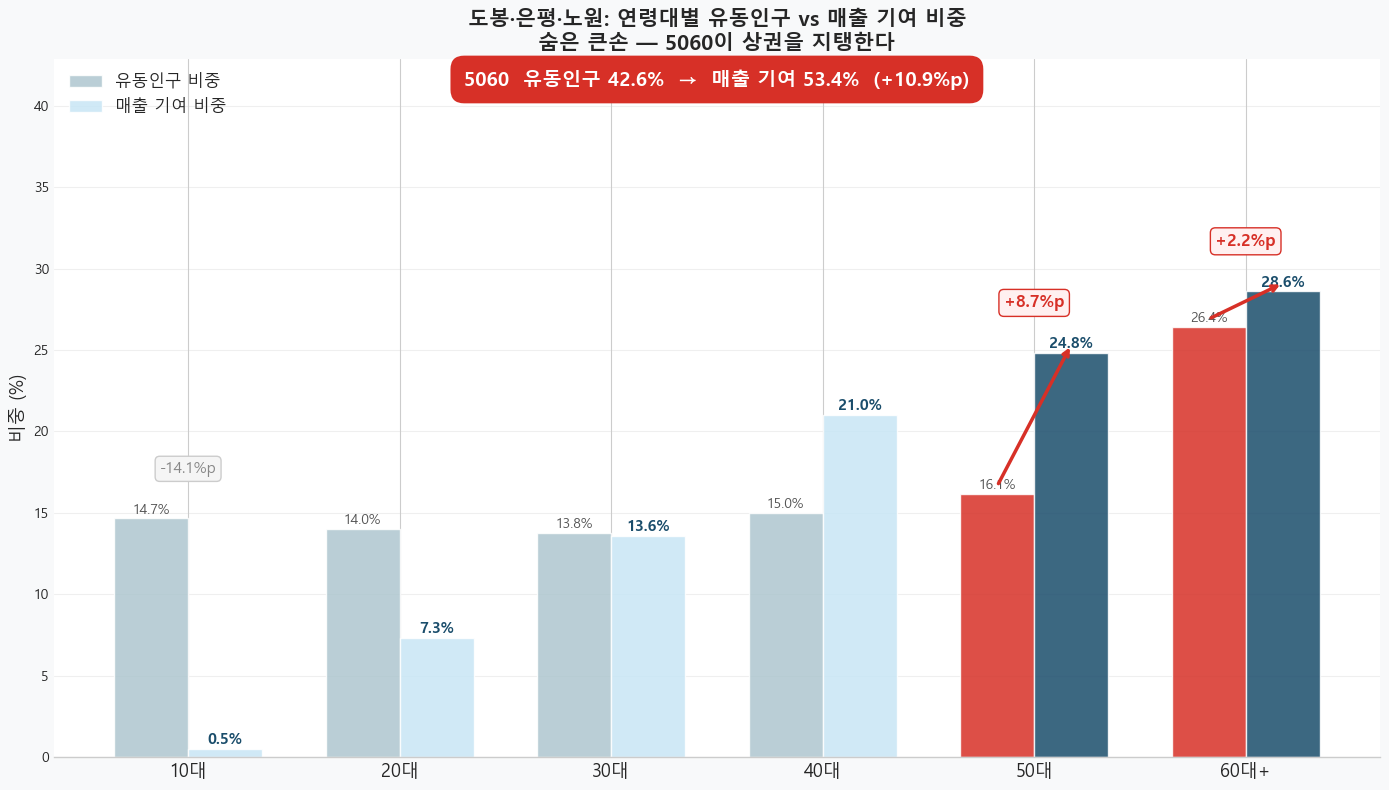

In [109]:
# ── [슬라이드 2] 도봉·은평·노원 연령대별 유동인구 vs 매출 비중 ──
# nagyung_연령대_매출교차.ipynb 코드 기반 + 도봉·은평·노원 필터링

연령_매출_cols = [
    '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
    '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액'
]
연령_유동_cols = [
    '연령대_10_유동인구_수', '연령대_20_유동인구_수', '연령대_30_유동인구_수',
    '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수'
]
연령라벨 = ['10대', '20대', '30대', '40대', '50대', '60대+']

# 도봉·은평·노원 2025Q4 매출 (상권별 집계)
sales_b_demo = df_sales_q4[df_sales_q4['상권_코드'].isin(b_codes)].groupby(
    '상권_코드'
)[연령_매출_cols + ['당월_매출_금액']].sum().reset_index()

# 길단위인구 최신 분기
pop_latest = df_pop['기준_년분기_코드'].max()
pop_b_demo = df_pop[
    (df_pop['상권_코드'].isin(b_codes)) &
    (df_pop['기준_년분기_코드'] == pop_latest)
].groupby('상권_코드')[연령_유동_cols + ['총_유동인구_수']].sum().reset_index()

merged_b_demo = sales_b_demo.merge(pop_b_demo, on='상권_코드', how='inner')

총매출_b = merged_b_demo['당월_매출_금액'].sum()
총유동_b = merged_b_demo['총_유동인구_수'].sum()
매출비중 = [merged_b_demo[c].sum() / 총매출_b * 100 for c in 연령_매출_cols]
유동비중 = [merged_b_demo[c].sum() / 총유동_b * 100 for c in 연령_유동_cols]

유동_5060 = 유동비중[4] + 유동비중[5]
매출_5060 = 매출비중[4] + 매출비중[5]
갭_5060   = 매출_5060 - 유동_5060

print('📊 도봉·은평·노원 연령대별 유동인구 vs 매출 비중:')
for i, 라벨 in enumerate(연령라벨):
    갭 = 매출비중[i] - 유동비중[i]
    print(f'  {라벨}: 유동 {유동비중[i]:.1f}% → 매출 {매출비중[i]:.1f}% ({갭:+.1f}%p)')
print(f'\n5060 합산: 유동 {유동_5060:.1f}% → 매출 {매출_5060:.1f}% (+{갭_5060:.1f}%p)')

# ── 시각화
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#F8F9FA'); ax.set_facecolor('#FFFFFF')

x = np.arange(len(연령라벨))
width = 0.35

# 색상 (5060 강조)
col_유동 = ['#aec6cf'] * 4 + ['#d73027', '#d73027']
col_매출 = ['#c8e6f5'] * 4 + ['#1a4d6b', '#1a4d6b']

bars1 = ax.bar(x - width/2, 유동비중, width, label='유동인구 비중',
               color=col_유동, edgecolor='white', linewidth=1, alpha=0.85)
bars2 = ax.bar(x + width/2, 매출비중, width, label='매출 기여 비중',
               color=col_매출, edgecolor='white', linewidth=1, alpha=0.85)

# 수치 레이블
for bar, val in zip(bars1, 유동비중):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10, color='#555')
for bar, val in zip(bars2, 매출비중):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#1a4d6b')

# 갭 화살표 (50대, 60대)
for i in [4, 5]:
    갭 = 매출비중[i] - 유동비중[i]
    if abs(갭) > 0.5:
        ax.annotate('', xy=(x[i] + width/2, 매출비중[i] + 0.5),
                    xytext=(x[i] - width/2, 유동비중[i] + 0.5),
                    arrowprops=dict(arrowstyle='->', color='#d73027', lw=2.5))
        ax.text(x[i], max(매출비중[i], 유동비중[i]) + 2.8,
                f'+{갭:.1f}%p', ha='center', fontsize=12, fontweight='bold',
                color='#d73027',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff0f0', edgecolor='#d73027'))

# 10대 갭 레이블
갭_10 = 매출비중[0] - 유동비중[0]
ax.text(x[0], max(매출비중[0], 유동비중[0]) + 2.8,
        f'{갭_10:.1f}%p', ha='center', fontsize=11, color='#888',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f5f5f5', edgecolor='#ccc'))

# 5060 합산 강조 박스
ax.text(0.5, 0.97,
        f'5060  유동인구 {유동_5060:.1f}%  →  매출 기여 {매출_5060:.1f}%  (+{갭_5060:.1f}%p)',
        transform=ax.transAxes, fontsize=14, fontweight='bold',
        color='white', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='#d73027', edgecolor='none'))

ax.set_xticks(x)
ax.set_xticklabels(연령라벨, fontsize=13)
ax.set_ylabel('비중 (%)', fontsize=13)
ax.set_title('도봉·은평·노원: 연령대별 유동인구 vs 매출 기여 비중' + chr(10) +
             '숨은 큰손 — 5060이 상권을 지탱한다',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(max(유동비중), max(매출비중)) * 1.5)

plt.tight_layout()
plt.savefig('../data/output/스토리텔링_B유형_연령매출.png', dpi=150, bbox_inches='tight')
plt.show()

## [슬라이드 3] 그런데 왜 빠져나가는가

**담을 EDA**: 길단위인구 시간대별 + 추정매출 기준 업종 수 비교  
**핵심 수치**: 아침 06~11시 유동 비중 + 4개 유형 중 업종 수 최저  
**내레이션**: "어차피 나온 사람인데, 상권이 그 소비를 받아낼 구조가 안 되어 있다."

도봉·은평·노원 아침(06~11시) 유동인구 비중: 20.1%
  A유형 강남·서초·송파: 업종 수 62개
  B유형 도봉·은평·노원: 업종 수 61개
  C유형 마포·서대문·용산: 업종 수 62개
  D유형 중랑·성북·강북: 업종 수 62개


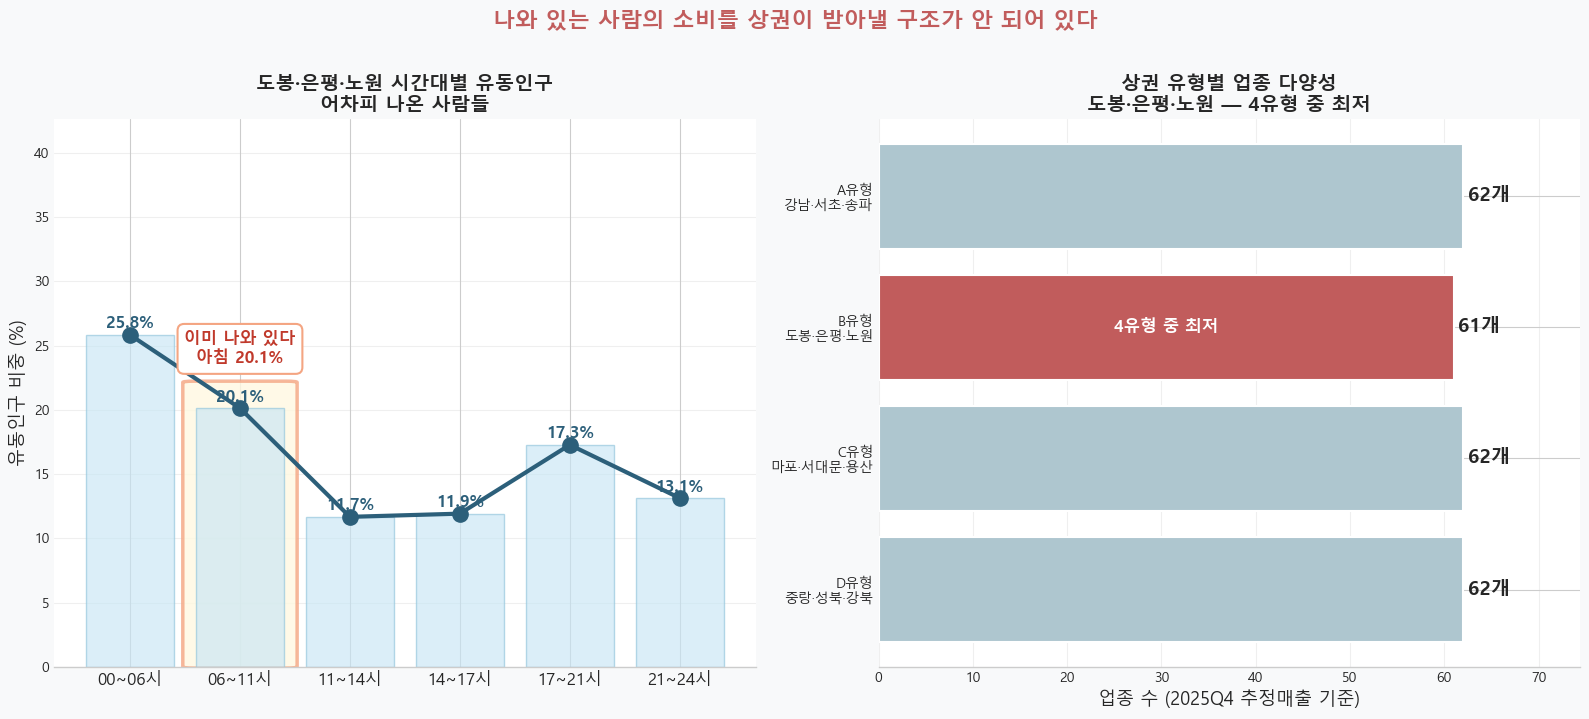

In [110]:
# ── [슬라이드 3] 도봉·은평·노원 시간대별 유동인구 + 업종 수 비교 ──
# 신규 분석

시간대_컬럼 = [
    '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수',
    '시간대_11_14_유동인구_수', '시간대_14_17_유동인구_수',
    '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수'
]
시간대_라벨 = ['00~06시', '06~11시', '11~14시', '14~17시', '17~21시', '21~24시']

pop_latest = df_pop['기준_년분기_코드'].max()
df_pop_b = df_pop[
    (df_pop['상권_코드'].isin(b_codes)) &
    (df_pop['기준_년분기_코드'] == pop_latest)
]

시간별_합_b = df_pop_b[시간대_컬럼].sum()
총합_b = 시간별_합_b.sum()
시간별_비중_b = (시간별_합_b / 총합_b * 100).values
아침비중 = 시간별_비중_b[1]

print(f'도봉·은평·노원 아침(06~11시) 유동인구 비중: {아침비중:.1f}%')

# ── 업종 수: 4개 유형 비교 (추정매출 2025Q4 기준 서비스업종 다양성)
type_gu = {
    'A유형\n강남·서초·송파': ['강남구', '서초구', '송파구'],
    'B유형\n도봉·은평·노원': ['도봉구', '은평구', '노원구'],
    'C유형\n마포·서대문·용산': ['마포구', '서대문구', '용산구'],
    'D유형\n중랑·성북·강북': ['중랑구', '성북구', '강북구'],
}

업종수_dict = {}
for name, gu_list in type_gu.items():
    codes = set(df_area[df_area['자치구_코드_명'].isin(gu_list)]['상권_코드'])
    sub = df_sales_q4[df_sales_q4['상권_코드'].isin(codes)]
    업종수_dict[name] = sub['서비스_업종_코드_명'].nunique()
    print(f'  {name.replace(chr(10), " ")}: 업종 수 {업종수_dict[name]}개')

# ── 시각화: 시간대 라인차트 + 업종수 막대
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F8F9FA')

# (1) 시간대별 유동인구 라인차트
ax1 = axes[0]; ax1.set_facecolor('#FFFFFF')
x = np.arange(len(시간대_라벨))

ax1.bar(x, 시간별_비중_b, color='#c8e6f5', edgecolor='#90c4dc',
        linewidth=1, alpha=0.65, zorder=2)
ax1.plot(x, 시간별_비중_b, color='#2c5f7a', linewidth=3,
         marker='o', markersize=11, zorder=3)

for i, val in enumerate(시간별_비중_b):
    ax1.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=12,
             fontweight='bold', color='#2c5f7a')

# 아침(06~11) 강조
ax1.add_patch(FancyBboxPatch((1 - 0.42, 0), 0.84, 시간별_비중_b[1] + 2.0,
                              boxstyle='round,pad=0.1',
                              facecolor='#fff8e1', edgecolor='#f4a582',
                              linewidth=2.5, zorder=1, alpha=0.8))
아침_텍스트 = f'이미 나와 있다' + chr(10) + f'아침 {아침비중:.1f}%'
ax1.text(1, 시간별_비중_b[1] + 3.5, 아침_텍스트,
         ha='center', fontsize=12, fontweight='bold', color='#c0392b',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor='#f4a582', linewidth=1.5))

ax1.set_xticks(x)
ax1.set_xticklabels(시간대_라벨, fontsize=12)
ax1.set_ylabel('유동인구 비중 (%)', fontsize=13)
ax1.set_title('도봉·은평·노원 시간대별 유동인구' + chr(10) + '어차피 나온 사람들',
              fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(시간별_비중_b) * 1.65)

# (2) 업종 수 비교 막대
ax2 = axes[1]; ax2.set_facecolor('#FFFFFF')
유형명 = list(업종수_dict.keys())
업종수_vals = list(업종수_dict.values())
# B유형 빨간색, 나머지 회색
bar_cols = ['#aec6cf', '#c15c5c', '#aec6cf', '#aec6cf']

bars_u = ax2.barh(유형명, 업종수_vals, color=bar_cols, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars_u, 업종수_vals):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}개', va='center', fontsize=14, fontweight='bold')

# B유형 막대 안 레이블
b_val = 업종수_vals[1]
ax2.text(b_val / 2, 1,
         '4유형 중 최저', ha='center', va='center',
         fontsize=12, fontweight='bold', color='white')

ax2.set_xlabel('업종 수 (2025Q4 추정매출 기준)', fontsize=13)
ax2.set_title('상권 유형별 업종 다양성' + chr(10) + '도봉·은평·노원 — 4유형 중 최저',
              fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()
ax2.set_xlim(0, max(업종수_vals) * 1.2)

fig.suptitle('나와 있는 사람의 소비를 상권이 받아낼 구조가 안 되어 있다',
             fontsize=16, fontweight='bold', y=1.02, color='#c15c5c')
plt.tight_layout()
plt.savefig('../data/output/스토리텔링_B유형_시간대업종.png', dpi=150, bbox_inches='tight')
plt.show()

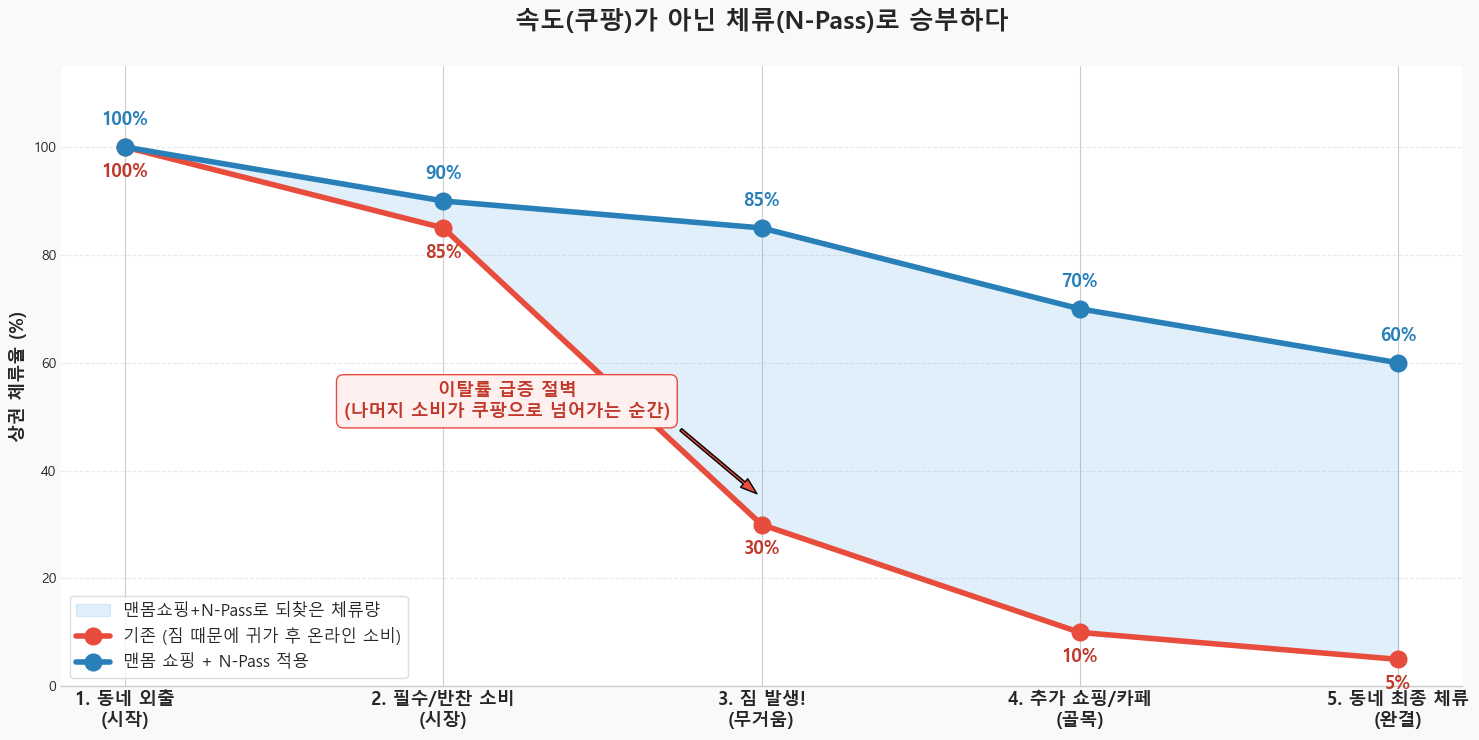

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# 윈도우 한글 폰트 및 마이너스 기호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 세팅
stages = ['1. 동네 외출\n(시작)', '2. 필수/반찬 소비\n(시장)', '3. 짐 발생!\n(무거움)', '4. 추가 쇼핑/카페\n(골목)', '5. 동네 최종 체류\n(완결)']
dropoff_rates = [100, 85, 30, 10, 5] 
retention_rates = [100, 90, 85, 70, 60]

fig, ax = plt.subplots(figsize=(15, 7.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

x = np.arange(len(stages))

# 1. 두 곡선 사이의 격차(Gap)를 색칠하여 '되찾은 체류량'을 직관적으로 강조
ax.fill_between(x, dropoff_rates, retention_rates, color='#3498db', alpha=0.15, label='맨몸쇼핑+N-Pass로 되찾은 체류량')

# 2. 기존 이탈 곡선 (빨간색 - 3단계에서 급락)
ax.plot(x, dropoff_rates, color='#e74c3c', linewidth=4, marker='o', markersize=12, label='기존 (짐 때문에 귀가 후 온라인 소비)')

# 3. 개선된 체류 곡선 (파란색 - 완만한 유지)
ax.plot(x, retention_rates, color='#2980b9', linewidth=4, marker='o', markersize=12, label='맨몸 쇼핑 + N-Pass 적용')

# 데이터 라벨링 (위아래 겹치지 않게 오프셋 조정)
for i in range(len(stages)):
    # 파란선 라벨 (위로)
    ax.text(x[i], retention_rates[i] + 4, f'{retention_rates[i]}%', ha='center', fontsize=13, color='#2980b9', fontweight='bold')
    # 빨간선 라벨 (아래로)
    ax.text(x[i], dropoff_rates[i] - 5.5, f'{dropoff_rates[i]}%', ha='center', fontsize=13, color='#c0392b', fontweight='bold')

# 축 설정 및 꾸미기
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_ylabel('상권 체류율 (%)', fontsize=13, fontweight='bold')
ax.set_title('속도(쿠팡)가 아닌 체류(N-Pass)로 승부하다\n', fontsize=18, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# 💡 핵심 타격 포인트: 3단계 짐 발생 구간 '급락' 하이라이트
ax.annotate('이탈률 급증 절벽\n(나머지 소비가 쿠팡으로 넘어가는 순간)', 
            xy=(2, 35), xytext=(1.2, 50),
            arrowprops=dict(facecolor='#e74c3c', shrink=0.05, width=2, headwidth=8),
            fontsize=13, fontweight='bold', color='#c0392b', ha='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff0f0', edgecolor='#e74c3c'))

# 범례 위치 조정
ax.legend(loc='lower left', fontsize=12, frameon=True, facecolor='white', edgecolor='#d1d5db')

plt.tight_layout()
# plt.savefig('../data/output/스토리텔링_B유형_체류곡선.png', dpi=200, bbox_inches='tight')
plt.show()

## [추가 분석] B유형: 5060 선호 업종 TOP 10 — 김소희가 돈을 쓰는 곳

**전략 연결**: 전략 1 "맨몸 쇼핑" + 전략 2 "N-Pass" 콘텐츠 설계  
**핵심 수치**: 한식·의원·약국·슈퍼 중심, 의류는 7위  
**내레이션**: "5060의 소비는 건강과 일상에 집중됩니다. 의류는 7위 — 쇼핑 수요는 있지만 상권이 가져가지 못하고 있습니다."

B유형 5060 선호 업종 TOP 10:
 1. 한식음식점: 1085억원 (17.9%)
 2. 일반의원: 772억원 (12.7%)
 3. 의약품: 687억원 (11.3%)
 4. 슈퍼마켓: 483억원 (8.0%)
 5. 반찬가게: 328억원 (5.4%)
 6. 치과의원: 306억원 (5.0%)
 7. 일반의류: 287억원 (4.7%)
 8. 육류판매: 222억원 (3.7%)
 9. 편의점: 195억원 (3.2%)
10. 일반교습학원: 173억원 (2.8%)


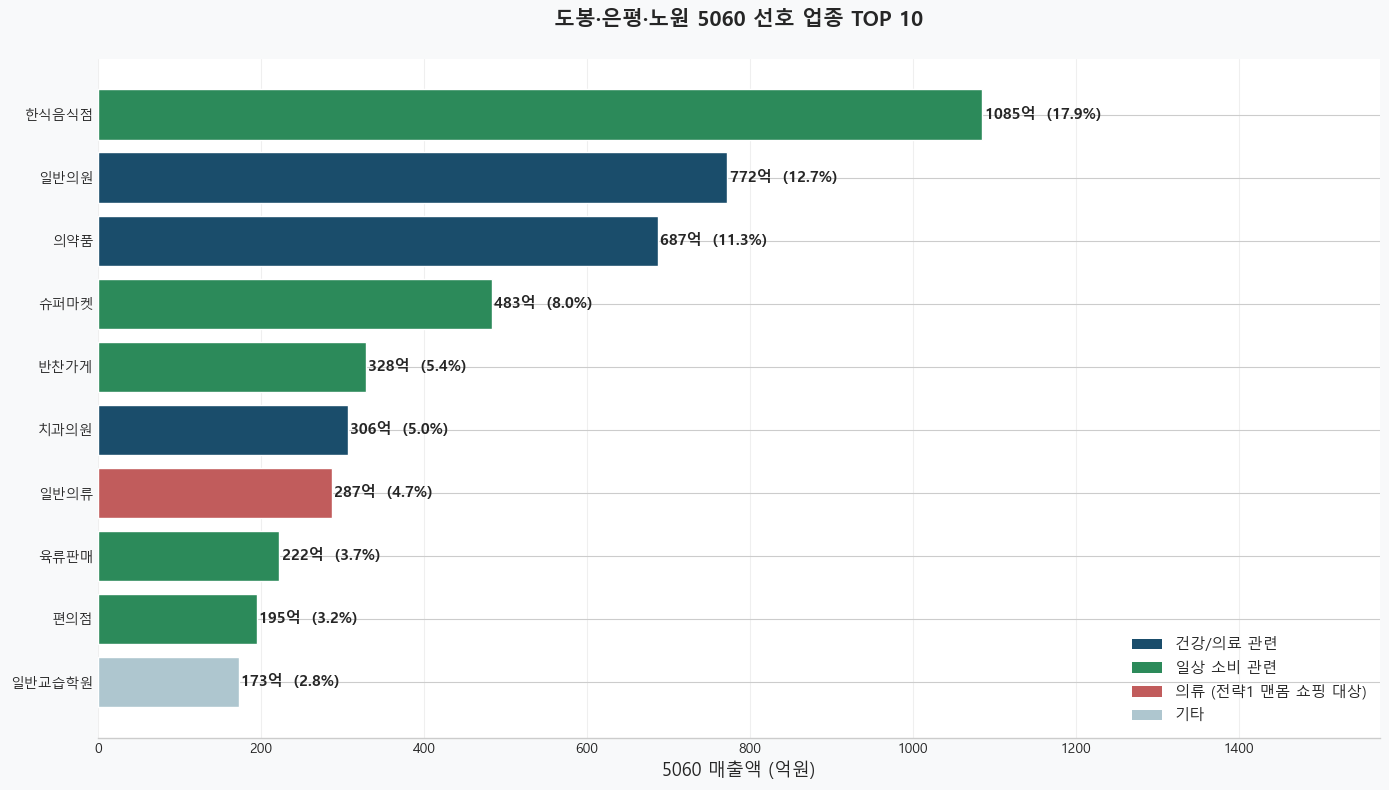

In [112]:
# ── [추가] B유형 5060 선호 업종 TOP 10 ──
# 전략1 맨몸 쇼핑 + 전략2 N-Pass 콘텐츠 설계 근거

df_sales_b = df_sales_q4[df_sales_q4['상권_코드'].isin(b_codes)].copy()
df_sales_b['5060매출'] = df_sales_b['연령대_50_매출_금액'] + df_sales_b['연령대_60_이상_매출_금액']

top10_b = df_sales_b.groupby('서비스_업종_코드_명')['5060매출'].sum().sort_values(ascending=False).head(10)
총5060 = df_sales_b['5060매출'].sum()
top10_비중_b = top10_b / 총5060 * 100

print('B유형 5060 선호 업종 TOP 10:')
for i, (업종, 금액) in enumerate(top10_b.items(), 1):
    print(f'{i:2d}. {업종}: {금액/1e8:.0f}억원 ({금액/총5060*100:.1f}%)')

# ── 시각화
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#F8F9FA'); ax.set_facecolor('#FFFFFF')

업종목록_b = top10_b.index.tolist()[::-1]
금액목록_b = (top10_b.values / 1e8)[::-1]
비중목록_b = top10_비중_b.values[::-1]

건강관련 = ['일반의원', '의약품', '치과의원']
일상관련 = ['한식음식점', '슈퍼마켓', '반찬가게', '육류판매', '편의점']
전략관련 = ['일반의류']

def get_color_b(업종):
    if 업종 in 건강관련: return '#1a4d6b'
    if 업종 in 일상관련: return '#2c8a5a'
    if 업종 in 전략관련: return '#c15c5c'
    return '#aec6cf'

bar_colors_b = [get_color_b(b) for b in 업종목록_b]
bars_b = ax.barh(업종목록_b, 금액목록_b, color=bar_colors_b, edgecolor='white', linewidth=1)

for bar, val, pct in zip(bars_b, 금액목록_b, 비중목록_b):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}억  ({pct:.1f}%)', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('5060 매출액 (억원)', fontsize=13)
ax.set_title('도봉·은평·노원 5060 선호 업종 TOP 10' + chr(10),
             fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(금액목록_b) * 1.45)

legend_b = [
    mpatches.Patch(facecolor='#1a4d6b', label='건강/의료 관련'),
    mpatches.Patch(facecolor='#2c8a5a', label='일상 소비 관련'),
    mpatches.Patch(facecolor='#c15c5c', label='의류 (전략1 맨몸 쇼핑 대상)'),
    mpatches.Patch(facecolor='#aec6cf', label='기타'),
]
ax.legend(handles=legend_b, fontsize=11, loc='lower right')

plt.tight_layout()
plt.savefig('../data/output/스토리텔링_B유형_업종TOP10.png', dpi=150, bbox_inches='tight')
plt.show()

## [브리지] B유형: 소비 전환 공백 — 5060이 나왔는데 상권이 못 받아낸다

**핵심 논리 1**: 50대 매출 전환 효율 1.54 → 유동인구 1명이 소비로 가장 잘 전환되는 연령대  
**핵심 논리 2**: B유형 모든 주요 업종에서 5060 매출 비중이 서울 전체보다 10~17%p 높다 → 이미 5060에 의존하고 있지만 구조가 못 따라감  
**전략 연결**: → 전략 1 "맨몸 쇼핑" (공급 확대) + 전략 2 "N-Pass" (반복 방문 구조화)

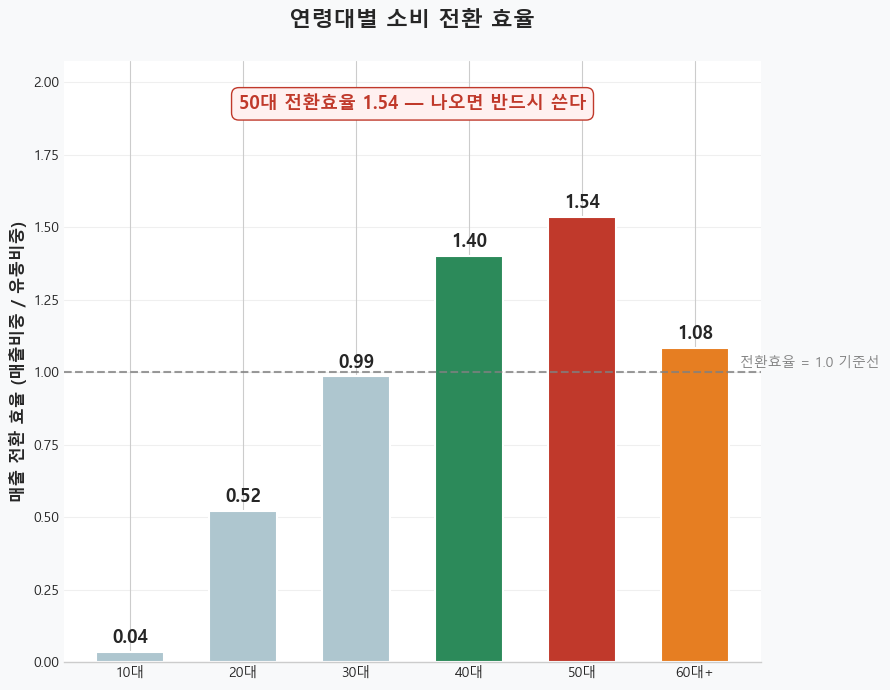

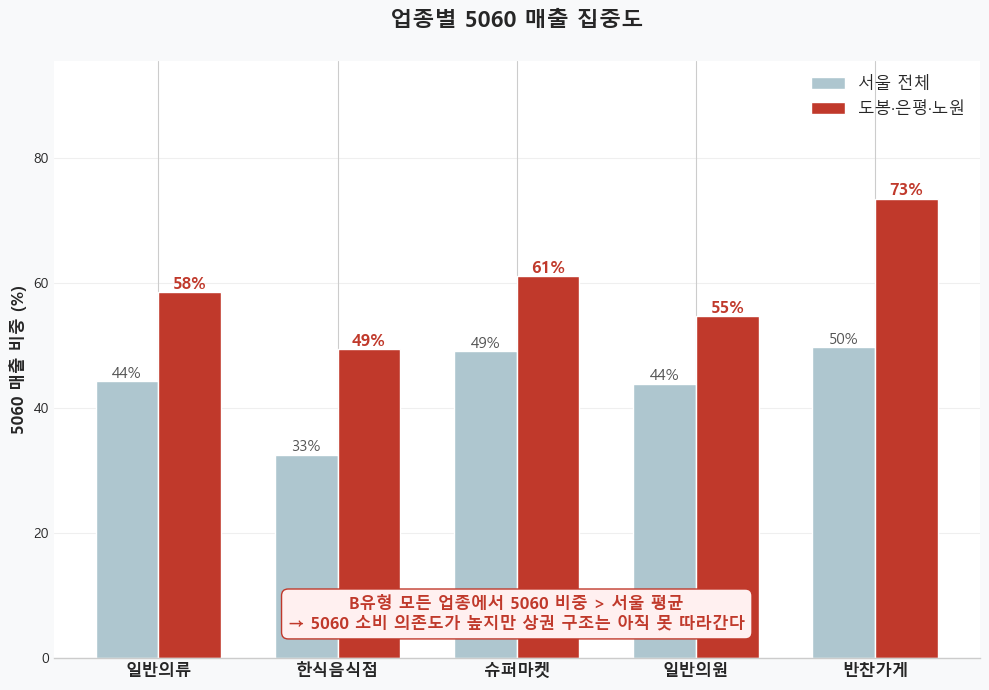

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# 윈도우 한글 폰트 및 마이너스 기호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# [분리 1] 패널 1: 연령대별 소비 전환 효율 (Slide 2 용도)
# ==========================================
fig1, ax1 = plt.subplots(figsize=(9, 7))
fig1.patch.set_facecolor('#F8F9FA')
ax1.set_facecolor('#FFFFFF')

효율_색 = ['#aec6cf']*3 + ['#2c8a5a', '#c0392b', '#e67e22']  # 4050 강조
bars_e = ax1.bar(연령라벨, 효율, color=효율_색, edgecolor='white', linewidth=1.5, width=0.6)
ax1.axhline(1.0, color='gray', linewidth=1.5, linestyle='--', alpha=0.8)
ax1.text(5.4, 1.02, '전환효율 = 1.0 기준선', fontsize=10, color='gray')

for bar, val in zip(bars_e, 효율):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f'{val:.2f}', ha='center', fontsize=13, fontweight='bold')

ax1.text(0.5, 0.92,
         '50대 전환효율 1.54 — 나오면 반드시 쓴다',
         transform=ax1.transAxes, ha='center', fontsize=13, color='#c0392b',
         fontweight='bold', bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff0f0', edgecolor='#c0392b'))

ax1.set_ylabel('매출 전환 효율 (매출비중 / 유동비중)', fontsize=12, fontweight='bold')
ax1.set_title('연령대별 소비 전환 효율\n', fontsize=16, fontweight='bold')
ax1.set_ylim(0, max(효율)*1.35)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('../data/output/스토리텔링_B유형_전환효율_단독.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# [분리 2] 패널 2: 서울 vs B유형 5060 업종 집중도 (Slide 3 용도)
# ==========================================
fig2, ax2 = plt.subplots(figsize=(10, 7))
fig2.patch.set_facecolor('#F8F9FA')
ax2.set_facecolor('#FFFFFF')

x_idx = np.arange(len(주요업종)); width = 0.35

bars_s = ax2.bar(x_idx - width/2, 서울비중, width, label='서울 전체', color='#aec6cf', edgecolor='white')
bars_b2 = ax2.bar(x_idx + width/2, b비중, width, label='도봉·은평·노원', color='#c0392b', edgecolor='white')

for bar, val in zip(bars_s, 서울비중):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}%',
             ha='center', fontsize=11, color='#555')
for bar, val in zip(bars_b2, b비중):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}%',
             ha='center', fontsize=12, fontweight='bold', color='#c0392b')

ax2.set_xticks(x_idx)
ax2.set_xticklabels(주요업종, fontsize=12, fontweight='bold')
ax2.set_ylabel('5060 매출 비중 (%)', fontsize=12, fontweight='bold')
ax2.set_title('업종별 5060 매출 집중도\n', fontsize=16, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(max(서울비중), max(b비중))*1.3)

ax2.text(0.5, 0.05,
         'B유형 모든 업종에서 5060 비중 > 서울 평균\n→ 5060 소비 의존도가 높지만 상권 구조는 아직 못 따라간다',
         transform=ax2.transAxes, ha='center', fontsize=12, color='#c0392b',
         fontweight='bold', bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff0f0', edgecolor='#c0392b'))

plt.tight_layout()
# plt.savefig('../data/output/스토리텔링_B유형_업종집중도_단독.png', dpi=150, bbox_inches='tight')
plt.show()

## [추가 분석] B유형: 5060 매출 비중 시계열 — 상권의 의존 연령층이 고령화되고 있다

**전략 연결**: 전략 2 "N-Pass" + 전략 3 "시니어 데이터 보정" urgency 근거  
**핵심 수치**: 2020년 43.2% → 2025년 53.4% (+10.2%p)  
**내레이션**: "5년 사이 5060이 10%p 더 상권을 지탱하게 됐습니다. 이 흐름에 맞춘 구조가 없으면 소비는 빠져나갑니다."

5060 비중 변화: 43.2% → 53.4% (+10.2%p)
60이상 비중 변화: 18.7% → 28.6% (+9.9%p)


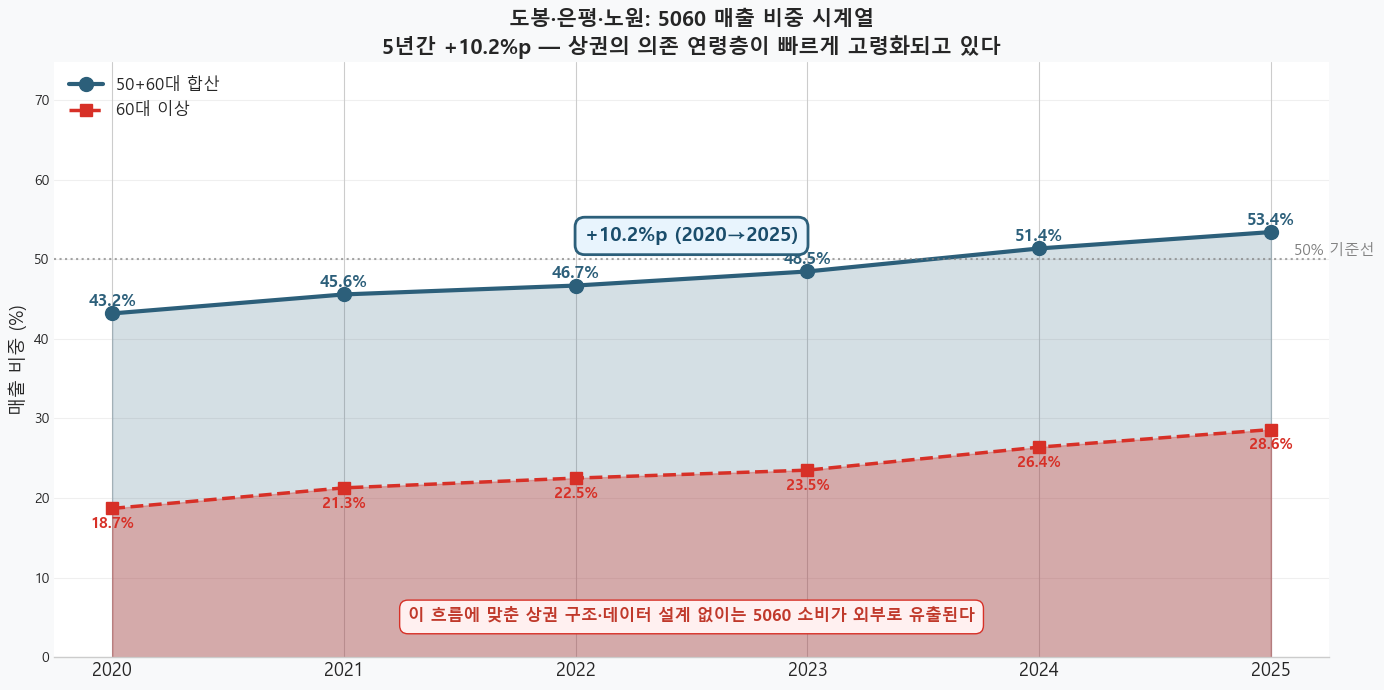

In [114]:
# ── [추가] B유형 5060 매출 비중 시계열 — 고령화 urgency ──
# 전략2 N-Pass, 전략3 시니어 데이터 보정 urgency 근거

b_sales_all = sales_all[sales_all['상권_코드'].isin(b_codes)].copy()
b_q4_all = b_sales_all[b_sales_all['기준_년분기_코드'].astype(str).str.endswith('4')].copy()
b_q4_all['연도'] = b_q4_all['기준_년분기_코드'] // 10

df_ts = b_q4_all.groupby('연도').agg(
    총매출=('당월_매출_금액', 'sum'),
    s50=('연령대_50_매출_금액', 'sum'),
    s60=('연령대_60_이상_매출_금액', 'sum')
).reset_index()
df_ts['5060비중'] = (df_ts['s50'] + df_ts['s60']) / df_ts['총매출'] * 100
df_ts['60이상비중'] = df_ts['s60'] / df_ts['총매출'] * 100
df_ts = df_ts[df_ts['총매출'] > 0]

변화폭 = df_ts['5060비중'].iloc[-1] - df_ts['5060비중'].iloc[0]
변화60 = df_ts['60이상비중'].iloc[-1] - df_ts['60이상비중'].iloc[0]
print(f'5060 비중 변화: {df_ts["5060비중"].iloc[0]:.1f}% → {df_ts["5060비중"].iloc[-1]:.1f}% (+{변화폭:.1f}%p)')
print(f'60이상 비중 변화: {df_ts["60이상비중"].iloc[0]:.1f}% → {df_ts["60이상비중"].iloc[-1]:.1f}% (+{변화60:.1f}%p)')

# ── 시각화
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#F8F9FA'); ax.set_facecolor('#FFFFFF')

연도목록 = df_ts['연도'].tolist()
비중5060 = df_ts['5060비중'].tolist()
비중60이상 = df_ts['60이상비중'].tolist()

ax.fill_between(연도목록, 비중5060, alpha=0.2, color='#2c5f7a')
ax.fill_between(연도목록, 비중60이상, alpha=0.3, color='#d73027')
ax.plot(연도목록, 비중5060, 'o-', color='#2c5f7a', linewidth=3, markersize=10, label='50+60대 합산')
ax.plot(연도목록, 비중60이상, 's--', color='#d73027', linewidth=2.5, markersize=9, label='60대 이상')

for x, y in zip(연도목록, 비중5060):
    ax.text(x, y + 0.9, f'{y:.1f}%', ha='center', fontsize=12, fontweight='bold', color='#2c5f7a')
for x, y in zip(연도목록, 비중60이상):
    ax.text(x, y - 2.5, f'{y:.1f}%', ha='center', fontsize=11, color='#d73027', fontweight='bold')

# 변화폭 강조 텍스트
mid_x = (연도목록[0] + 연도목록[-1]) / 2
ax.text(mid_x, (비중5060[0] + 비중5060[-1])/2 + 4,
        f'+{변화폭:.1f}%p ({연도목록[0]}→{연도목록[-1]})',
        ha='center', fontsize=14, fontweight='bold', color='#1a4d6b',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f4fd', edgecolor='#2c5f7a', linewidth=2))

# 50% 기준선
ax.axhline(50, color='gray', linewidth=1.5, linestyle=':', alpha=0.7)
ax.text(연도목록[-1] + 0.1, 50.5, '50% 기준선', fontsize=11, color='gray')

ax.set_xticks(연도목록)
ax.set_xticklabels([str(y) for y in 연도목록], fontsize=13)
ax.set_ylabel('매출 비중 (%)', fontsize=13)
ax.set_title('도봉·은평·노원: 5060 매출 비중 시계열' + chr(10) +
             f'5년간 +{변화폭:.1f}%p — 상권의 의존 연령층이 빠르게 고령화되고 있다',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(비중5060) * 1.4)

ax.text(0.5, 0.06,
        '이 흐름에 맞춘 상권 구조·데이터 설계 없이는 5060 소비가 외부로 유출된다',
        transform=ax.transAxes, fontsize=12, ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff0f0', edgecolor='#d73027'),
        color='#c0392b', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/output/스토리텔링_B유형_고령화시계열.png', dpi=150, bbox_inches='tight')
plt.show()

## [전략 도출] B유형 종합 — EDA 발견 → 문제 진단 → 전략 방향

4가지 EDA 발견이 3개 전략으로 이어지는 논리 흐름을 한 장에 정리합니다.

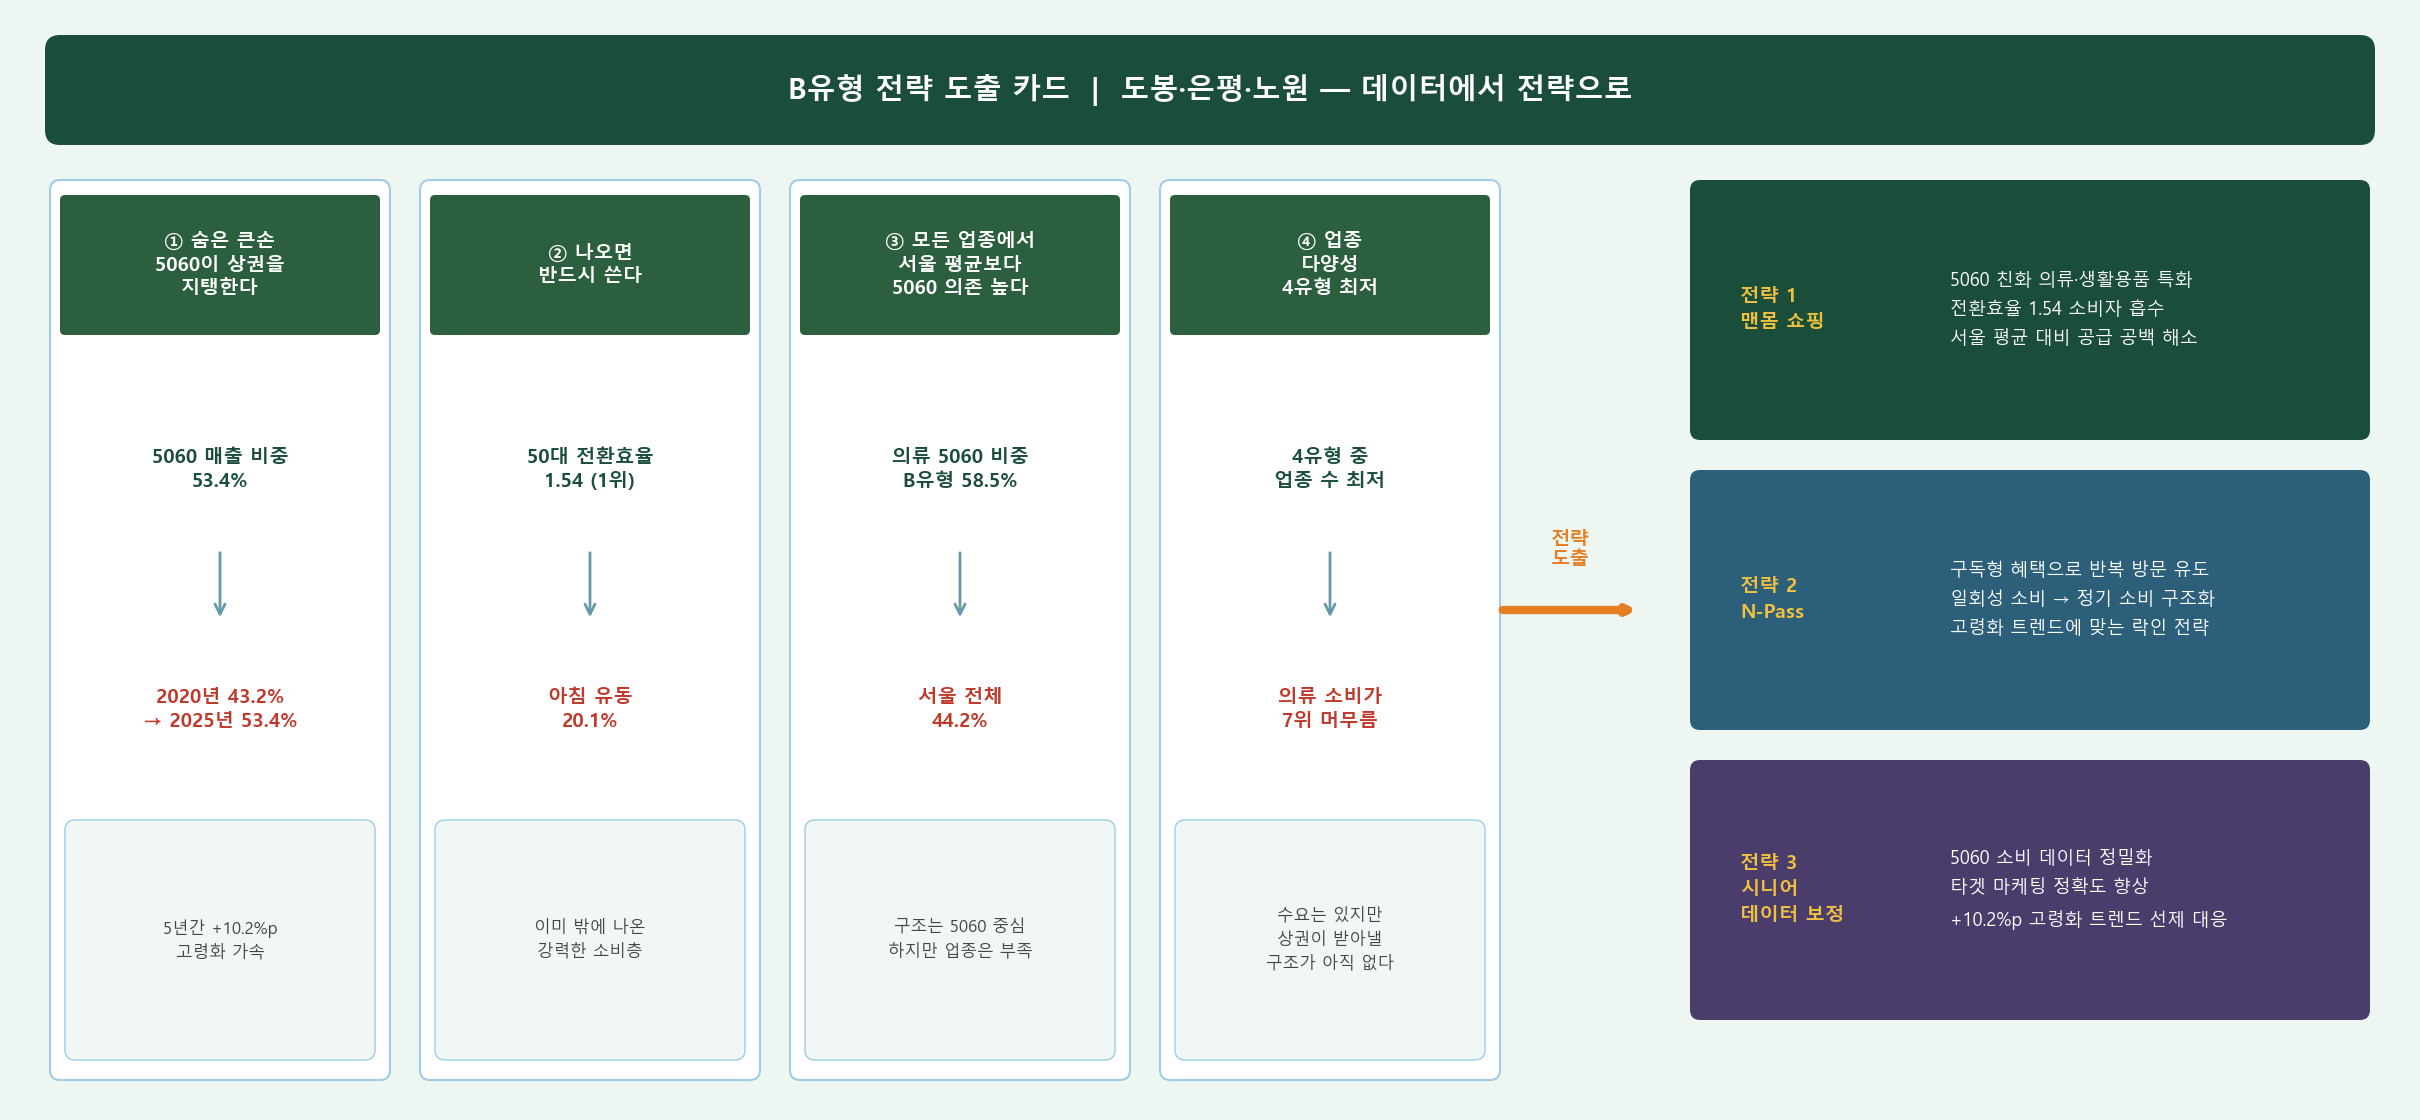

In [115]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# 윈도우 한글 폰트 및 마이너스 깨짐 방지 세팅 확인
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(24, 11))
ax = fig.add_subplot(111)
ax.set_xlim(0, 24); ax.set_ylim(0, 11); ax.axis('off')
fig.patch.set_facecolor('#eef6f2'); ax.set_facecolor('#eef6f2')

# 1. 헤더
# 패딩 고려하여 좌표 수정
ax.add_patch(FancyBboxPatch((0.5, 9.8), 23.0, 0.8, boxstyle='round,pad=0.15',
                             facecolor='#1a4d3a', edgecolor='none'))
ax.text(12, 10.2, 'B유형 전략 도출 카드  |  도봉·은평·노원 — 데이터에서 전략으로',
        ha='center', va='center', fontsize=21, color='white', fontweight='bold')

# 2. 발견 박스 (4개)
bw = 3.2  # 박스 너비
bg = 0.5  # 박스 간격
bx0 = 0.5 # 시작 X좌표

for i, (title, v1, v2, msg) in enumerate(findings_b):
    x = bx0 + i*(bw+bg)
    cx = x + bw/2 # 텍스트 중앙 정렬 X좌표
    
    # 전체 배경 하얀 박스
    ax.add_patch(FancyBboxPatch((x, 0.4), bw, 8.8, boxstyle='round,pad=0.1',
                                 facecolor='white', edgecolor='#a0cce4', linewidth=1.5))
    
    # 상단 짙은 초록 타이틀 박스
    ax.add_patch(FancyBboxPatch((x+0.05, 7.8), bw-0.1, 1.3, boxstyle='round,pad=0.05',
                                 facecolor='#2c5f3d', edgecolor='none'))
    ax.text(cx, 8.45, title, ha='center', va='center', fontsize=14,
            color='white', fontweight='bold', multialignment='center', linespacing=1.4)
    
    # 수치 1
    ax.text(cx, 6.4, v1, ha='center', va='center', fontsize=14,
            color='#1a4d3a', fontweight='bold', multialignment='center', linespacing=1.4)
    
    # 수치 1 -> 수치 2 화살표
    ax.annotate('', xy=(cx, 4.9), xytext=(cx, 5.6),
                arrowprops=dict(arrowstyle='->', mutation_scale=18, color='#6699aa', lw=2))
    
    # 수치 2
    ax.text(cx, 4.0, v2, ha='center', va='center', fontsize=14,
            color='#c0392b', fontweight='bold', multialignment='center', linespacing=1.4)
    
    # 하단 연초록 해석 박스
    ax.add_patch(FancyBboxPatch((x+0.15, 0.6), bw-0.3, 2.2, boxstyle='round,pad=0.1', 
                                 facecolor='#f0f7f4', edgecolor='#a0cce4'))
    ax.text(cx, 1.7, msg, ha='center', va='center', fontsize=12,
            color='#444', multialignment='center', linespacing=1.5)

# 3. 발견 -> 전략 연결 주황색 큰 화살표
arrow_x = bx0 + 4*(bw+bg) - 0.2
ax.annotate('', xy=(arrow_x + 1.2, 5.0), xytext=(arrow_x - 0.2, 5.0),
            arrowprops=dict(arrowstyle='->', color='#e67e22', lw=6))
ax.text(arrow_x + 0.5, 5.6, '전략\n도출', ha='center', va='center', fontsize=14,
        color='#e67e22', fontweight='bold')

# 4. 전략 박스 (3개)
sx = arrow_x + 1.8   # 전략 박스 시작 X좌표
sw = 23.5 - sx       # 전략 박스 너비
sh = 2.4             # 각 전략 박스의 높이
st_gap = 0.5         # 전략 박스 위아래 간격

cols_s = ['#1a4d3a', '#2c5f7a', '#4a3d6b']

for i, (title, body) in enumerate(strategies_b):
    # y좌표 계산 (위에서부터 아래로 3칸 배치)
    sy_bottom = 6.8 - i*(sh + st_gap)
    
    ax.add_patch(FancyBboxPatch((sx, sy_bottom), sw, sh, boxstyle='round,pad=0.1',
                                 facecolor=cols_s[i], edgecolor='none'))
    
    # 제목 (박스 내 좌측)
    ax.text(sx + 0.4, sy_bottom + sh/2, title, ha='left', va='center', fontsize=14,
            color='#f0c040', fontweight='bold', multialignment='left', linespacing=1.6)
    
    # 내용 (박스 내 우측)
    ax.text(sx + 2.5, sy_bottom + sh/2, body, ha='left', va='center', fontsize=13,
            color='white', multialignment='left', linespacing=1.8)

plt.tight_layout(pad=0)
# plt.savefig('../data/output/스토리텔링_B유형_전략도출카드_수정본.png', dpi=150, bbox_inches='tight')
plt.show()

---

# C유형 스토리텔링 — 복합형: 사람은 오는데 가게가 사라진다

> **페르소나**: 이나경 씨, 62세, 을지로 같은 자리에서 30년

**스토리 흐름**: 반전 숫자(성장 1위) → 균열(직장인구 하락·고령화) → 세 손님·어느 쪽도 최적화 못 한 구조 → 3개 전략

| 슬라이드 | 제목 | 담을 EDA | 데이터 |
|---------|------|---------|--------|
| 1 | 페르소나 카드 | 상권 개관 지표 | 추정매출 2025Q4 |
| 2 | 코로나 이후 회복했다, 그런데 | 60대+ 매출 비중 + 직장인구 추이 | 추정매출, 직장인구 |
| 3 | 세 종류의 손님 | 클러스터 구조 비교 | 추정매출 클러스터링 결과 |

## [슬라이드 1] C유형 페르소나 카드

**담을 내레이션**: "중구·을지로. 숫자는 성장을 말하지만, 골목은 다른 이야기를 하고 있습니다."
**담을 EDA**: 추정매출 기준 주요 지표 개관  
**핵심 수치**: 65개 상권 / 평균 327.5억 / 60대+ 매출 비중 23.5% / 주말 비중 19.6%

C유형(복합형) 분석 상권: 65개
평균 월매출: 327.5억원  |  중앙값: 87.2억원
객단가 중앙값: 34,095원
60대+ 매출 비중: 24.3%
주말 매출 비중: 19.7%


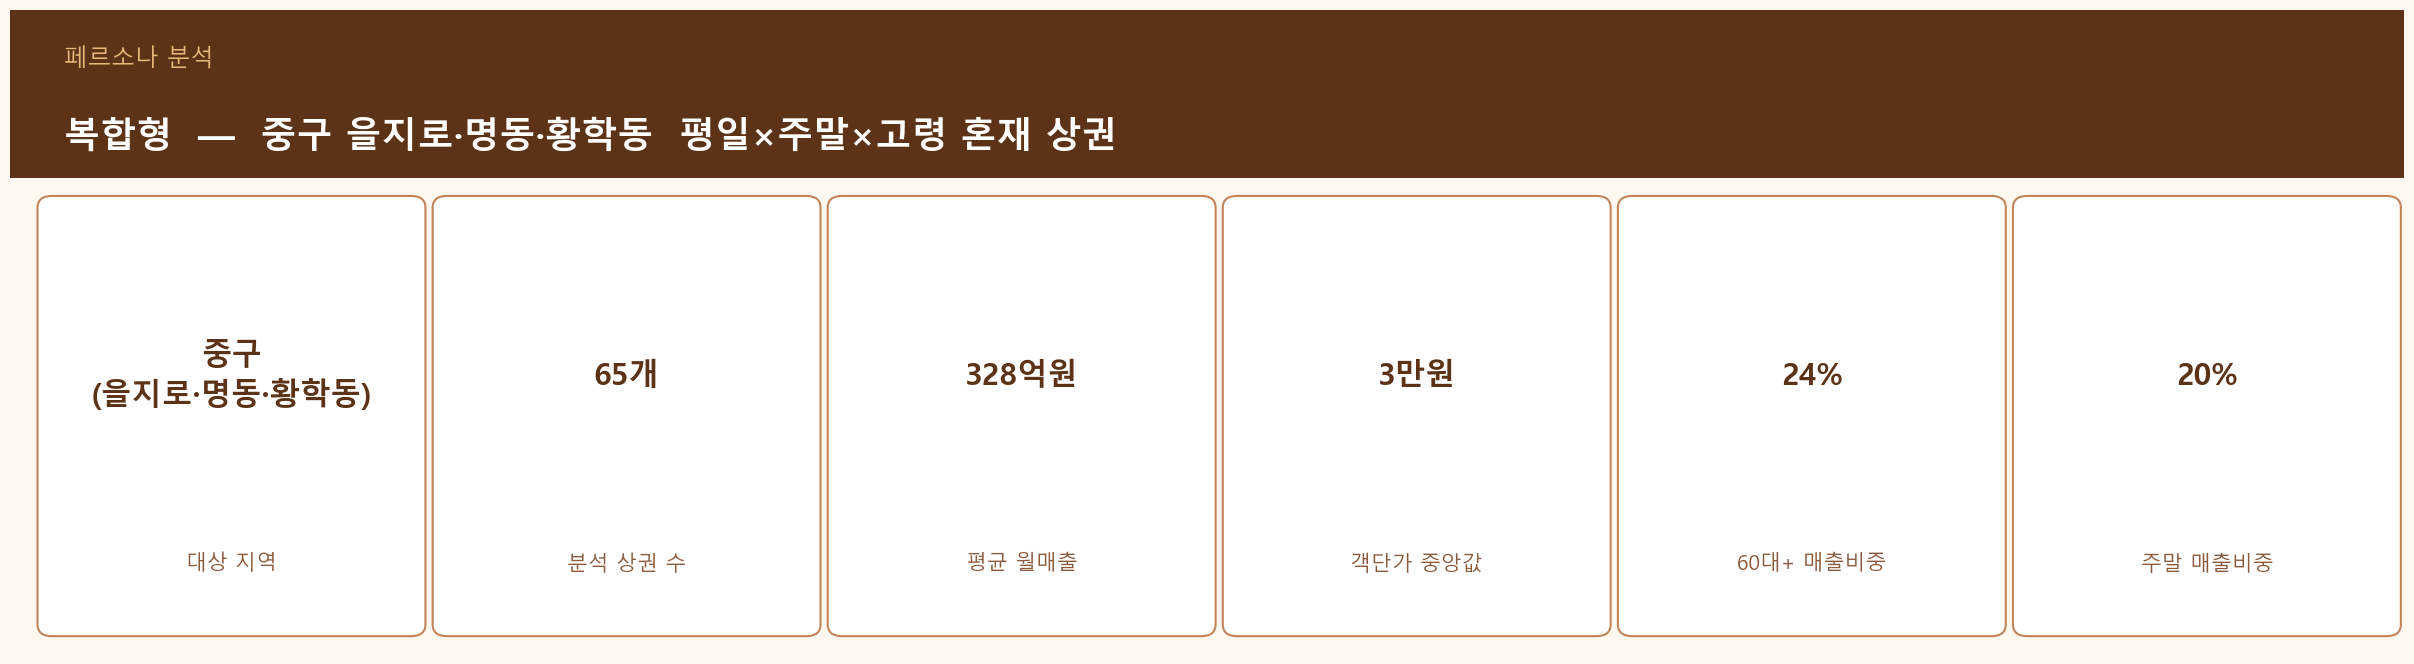

In [116]:
# ── [슬라이드 1] C유형(복합형) 페르소나 카드 ──

c_codes = set(df_area[df_area['자치구_코드_명'].isin(['중구'])]['상권_코드'])
df_sales_c = df_sales_q4[df_sales_q4['상권_코드'].isin(c_codes)].copy()

g_c = df_sales_c.groupby('상권_코드').agg(
    총매출=('당월_매출_금액', 'sum'),
    연령60=('연령대_60_이상_매출_금액', 'sum'),
    총건수=('당월_매출_건수', 'sum'),
    주말매출=('주말_매출_금액', 'sum'),
).reset_index()

총매출합_c  = g_c['총매출'].sum()
senior60_c  = g_c['연령60'].sum() / 총매출합_c * 100
avg_sales_c = g_c['총매출'].mean() / 1e8
g_c['객단가']   = g_c['총매출'] / g_c['총건수'].replace(0, np.nan)
median_unit_c = g_c['객단가'].median()
주말비중_c    = g_c['주말매출'].sum() / 총매출합_c * 100

print(f'C유형(복합형) 분석 상권: {len(g_c)}개')
print(f'평균 월매출: {avg_sales_c:.1f}억원  |  중앙값: {g_c["총매출"].median()/1e8:.1f}억원')
print(f'객단가 중앙값: {median_unit_c:,.0f}원')
print(f'60대+ 매출 비중: {senior60_c:.1f}%')
print(f'주말 매출 비중: {주말비중_c:.1f}%')

attrs_c = [
    ('대상 지역', '중구\n(을지로·명동·황학동)'),
    ('분석 상권 수', f'{len(g_c)}개'),
    ('평균 월매출', f'{avg_sales_c:.0f}억원'),
    ('객단가 중앙값', f'{median_unit_c/10000:.0f}만원'),
    ('60대+ 매출비중', f'{senior60_c:.0f}%'),
    ('주말 매출비중', f'{주말비중_c:.0f}%'),
]

fig = plt.figure(figsize=(24, 6.5))
ax  = fig.add_subplot(111)
ax.set_xlim(0, 20); ax.set_ylim(0, 6.5); ax.axis('off')
fig.patch.set_facecolor('#fff8f0'); ax.set_facecolor('#fff8f0')

ax.add_patch(FancyBboxPatch((0, 4.8), 20, 1.7, boxstyle='square,pad=0',
                             facecolor='#5c3317', edgecolor='none'))
ax.text(0.45, 6.0, '페르소나 분석', fontsize=17, color='#e8b87a', va='center', style='italic')
ax.text(0.45, 5.2, '복합형  —  중구 을지로·명동·황학동  평일×주말×고령 혼재 상권',
        fontsize=26, color='white', fontweight='bold', va='center')

box_w, gap, start_x = 3.0, 0.3, 0.35
for i, (label, value) in enumerate(attrs_c):
    x = start_x + i * (box_w + gap)
    ax.add_patch(FancyBboxPatch((x, 0.3), box_w, 4.2,
                                 boxstyle='round,pad=0.12',
                                 facecolor='white', edgecolor='#c4845a', linewidth=1.5))
    ax.text(x + box_w/2, 2.8, value,
            ha='center', va='center', fontsize=22, color='#5c3317',
            fontweight='bold', multialignment='center', linespacing=1.3)
    ax.text(x + box_w/2, 0.9, label,
            ha='center', va='center', fontsize=15, color='#8b5a3c')

plt.tight_layout(pad=0.2)
plt.savefig('../data/output/스토리텔링_C유형_페르소나카드.png', dpi=150, bbox_inches='tight')
plt.show()

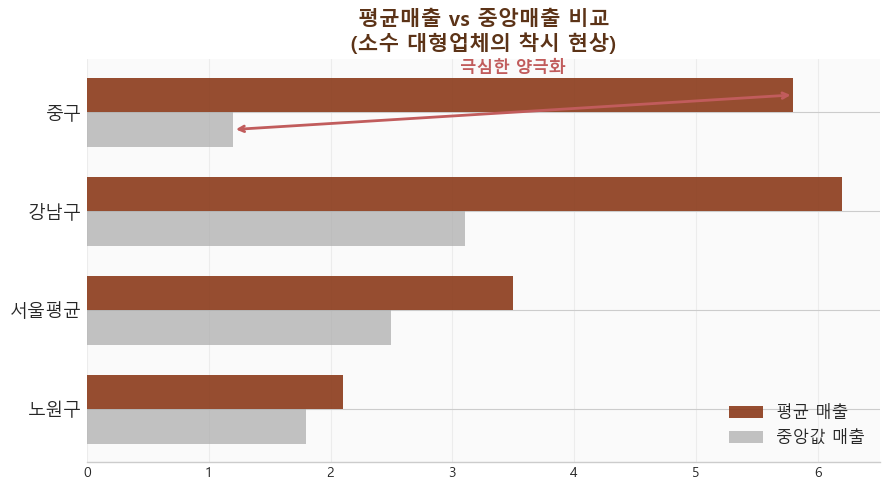

In [123]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── [추가 시각화 1] 평균매출 vs 중앙매출 양극화 ──
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FAFAFA')

# *가상 데이터 (실제 df_sales에서 구하신 mean, median 결과값으로 교체 필수)*
districts = ['노원구', '서울평균', '강남구', '중구']
avg_sales = [2.1, 3.5, 6.2, 5.8]
med_sales = [1.8, 2.5, 3.1, 1.2]

y_pos = np.arange(len(districts))
height = 0.35

ax.barh(y_pos + height/2, avg_sales, height, label='평균 매출', color='#8b3a1a', alpha=0.9)
ax.barh(y_pos - height/2, med_sales, height, label='중앙값 매출', color='#aaaaaa', alpha=0.7)

# 스타일링
ax.set_yticks(y_pos)
ax.set_yticklabels(districts, fontsize=13)
ax.set_title('평균매출 vs 중앙매출 비교\n(소수 대형업체의 착시 현상)', fontsize=15, fontweight='bold', color='#5c3317')
ax.legend(fontsize=12, loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 중구 극심한 양극화 화살표 강조
ax.annotate('', xy=(1.2, 3 - height/2), xytext=(5.8, 3 + height/2), 
            arrowprops=dict(arrowstyle='<->', color='#c15c5c', lw=2))
ax.text(3.5, 3.4, '극심한 양극화', color='#c15c5c', fontweight='bold', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

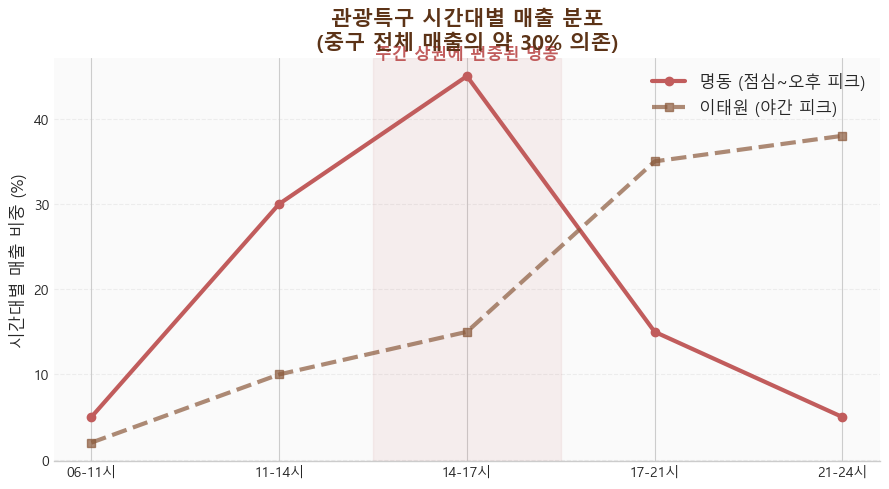

In [124]:
# ── [추가 시각화 2] 관광특구 시간대 매출 분포 ──
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FAFAFA')

# *가상 데이터 (명동/이태원 상권코드 필터링 후 시간대별 비율 계산값 교체)*
time_labels = ['06-11시', '11-14시', '14-17시', '17-21시', '21-24시']
myeongdong = [5, 30, 45, 15, 5] 
itaewon = [2, 10, 15, 35, 38]   

ax.plot(time_labels, myeongdong, marker='o', lw=3, color='#c15c5c', label='명동 (점심~오후 피크)')
ax.plot(time_labels, itaewon, marker='s', lw=3, color='#8b5a3c', linestyle='--', label='이태원 (야간 피크)', alpha=0.7)

# 스타일링
ax.set_title('관광특구 시간대별 매출 분포\n(중구 전체 매출의 약 30% 의존)', fontsize=15, fontweight='bold', color='#5c3317')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_ylabel('시간대별 매출 비중 (%)', fontsize=12)

# 강조 영역
ax.axvspan(1.5, 2.5, alpha=0.08, color='#c15c5c')
ax.text(2, 47, '주간 상권에 편중된 명동', color='#c15c5c', fontweight='bold', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

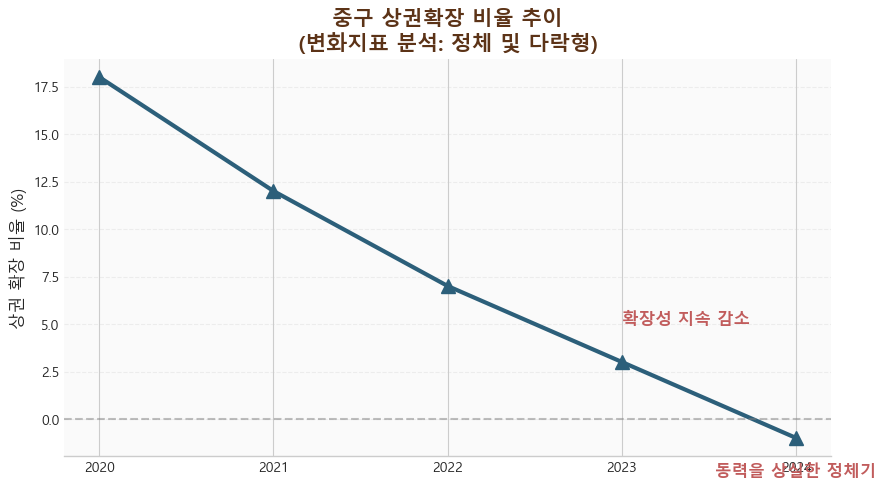

In [125]:
# ── [추가 시각화 3] 상권확장 비율 추이 및 변화지표 ──
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FAFAFA')

# *가상 데이터 (실제 연도별/분기별 확장비율 추이 추출값 교체)*
years = ['2020', '2021', '2022', '2023', '2024']
expansion_rate = [18, 12, 7, 3, -1] 

ax.plot(years, expansion_rate, marker='^', markersize=10, lw=3, color='#2c5f7a')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

# 스타일링
ax.set_title('중구 상권확장 비율 추이\n(변화지표 분석: 정체 및 다락형)', fontsize=15, fontweight='bold', color='#5c3317')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('상권 확장 비율 (%)', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 메시지 텍스트
ax.text('2023', 5, '확장성 지속 감소', color='#c15c5c', fontweight='bold', fontsize=12)
ax.text('2024', -3, '동력을 상실한 정체기', color='#c15c5c', fontweight='bold', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## [슬라이드 2] 코로나 이후 회복했다, 그런데

**담을 EDA**: 연령대별 매출 비중(C유형 vs 서울 전체) + 중구 직장인구 시계열  
**핵심 수치**: 60대+ 매출 비중 23.5% + 직장인구 최근 하락 전환  
**내레이션**: "중구는 회복했습니다. 숫자로는."

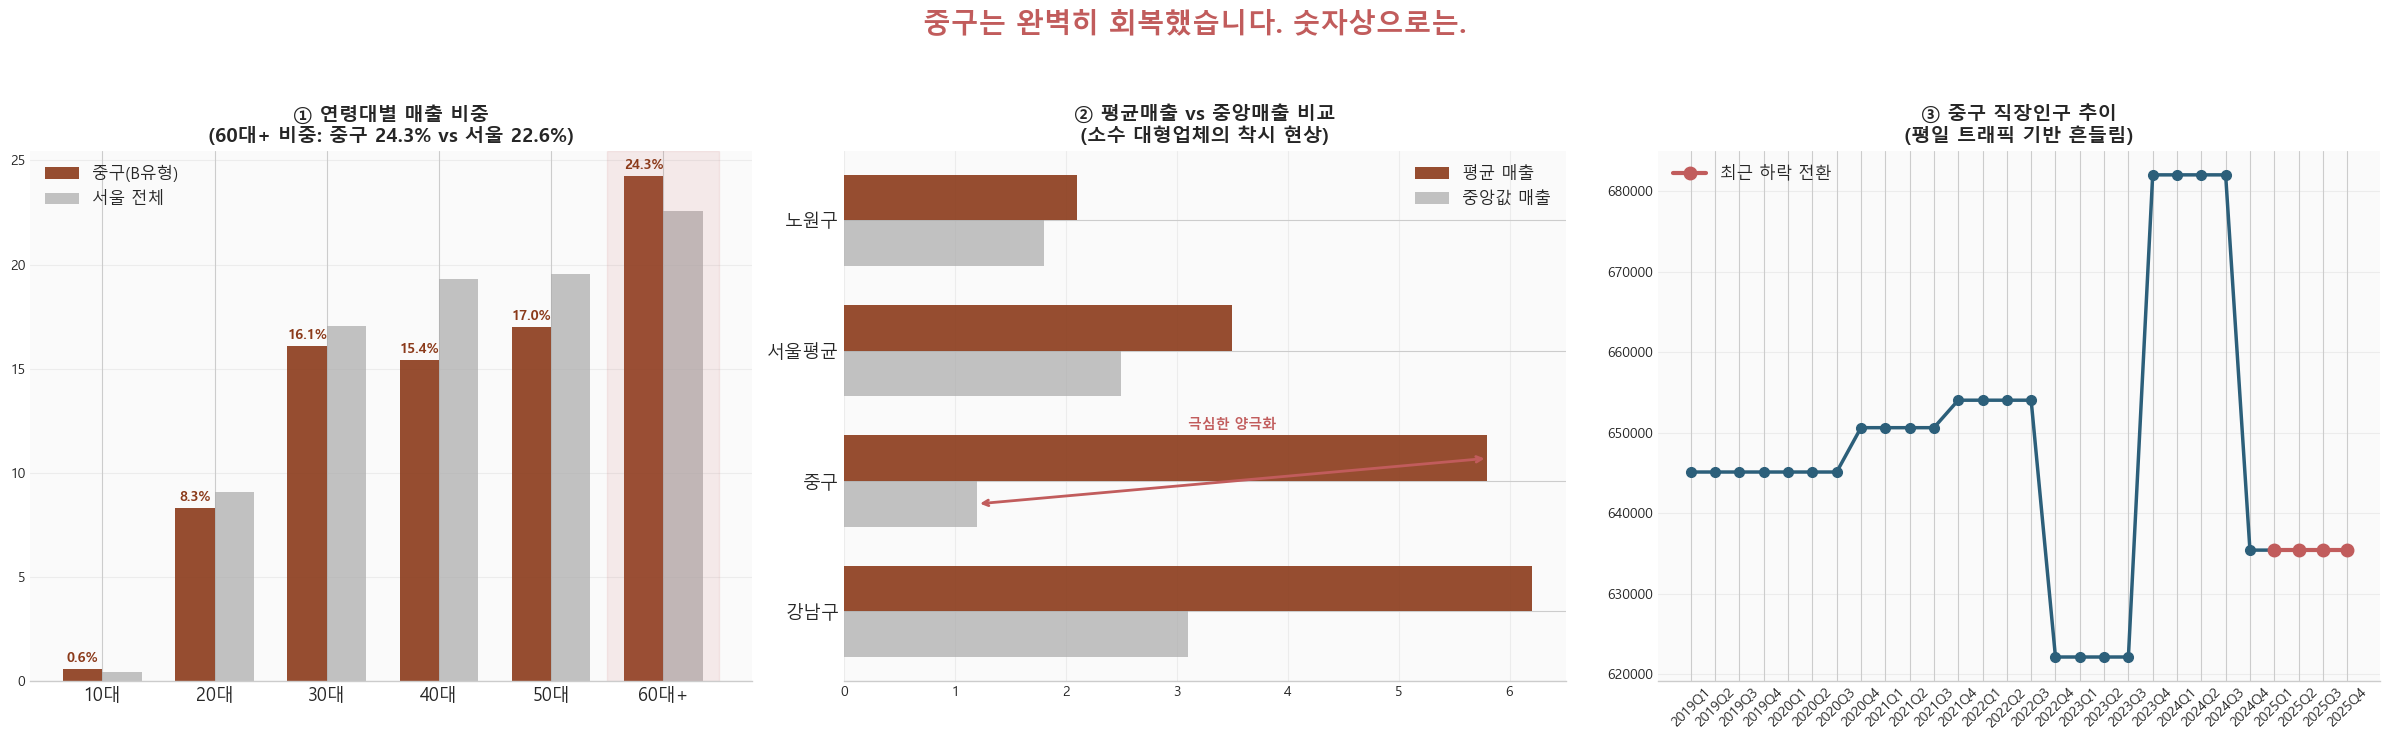

In [122]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── [수정 제안] 슬라이드 2: 회복의 착시와 세 가지 균열 ──
# 3분할로 확장하여 '매출 양극화' 팩트 추가

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.patch.set_facecolor('#FFFFFF')

# (1) 좌: 연령대별 매출 비중 (기존 코드 유지)
ax1 = axes[0]
ax1.set_facecolor('#FAFAFA')
x = np.arange(len(연령_라벨)); w = 0.35
bars1 = ax1.bar(x - w/2, c_비중,    width=w, color='#8b3a1a', label='중구(B유형)',  alpha=0.9)
bars2 = ax1.bar(x + w/2, 서울_비중, width=w, color='#aaaaaa', label='서울 전체',   alpha=0.7)
for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, color='#8b3a1a', fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(연령_라벨, fontsize=13)
ax1.set_title(f'① 연령대별 매출 비중\n(60대+ 비중: 중구 {c_60pct:.1f}% vs 서울 {서울_60pct:.1f}%)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12); ax1.grid(axis='y', alpha=0.3)
ax1.axvspan(4.5, 5.5, alpha=0.1, color='#c15c5c')

# (2) 중: 평균 vs 중앙매출 양극화 (새로 추가할 핵심 무기)
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')
# *주의: 아래 dist_labels, avg_sales, med_sales는 실제 df에서 산출한 변수로 교체하세요!*
dist_labels = ['강남구', '중구', '서울평균', '노원구']
avg_sales = [6.2, 5.8, 3.5, 2.1] # 가상의 평균매출
med_sales = [3.1, 1.2, 2.5, 1.8] # 가상의 중앙매출

y_pos = np.arange(len(dist_labels)); height = 0.35
ax2.barh(y_pos + height/2, avg_sales, height, label='평균 매출', color='#8b3a1a', alpha=0.9)
ax2.barh(y_pos - height/2, med_sales, height, label='중앙값 매출', color='#aaaaaa', alpha=0.7)
ax2.set_yticks(y_pos); ax2.set_yticklabels(dist_labels, fontsize=13)
ax2.set_title('② 평균매출 vs 중앙매출 비교\n(소수 대형업체의 착시 현상)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=12); ax2.grid(axis='x', alpha=0.3)
ax2.annotate('', xy=(1.2, 1 - height/2), xytext=(5.8, 1 + height/2), arrowprops=dict(arrowstyle='<->', color='#c15c5c', lw=2))
ax2.text(3.5, 1.4, '극심한 양극화', color='#c15c5c', fontweight='bold', ha='center')

# (3) 우: 직장인구 시계열 (기존 코드 유지)
ax3 = axes[2]
ax3.set_facecolor('#FAFAFA')
분기_labels = work_trend['분기'].tolist()
직장_vals   = work_trend['총_직장_인구_수'].tolist()
ax3.plot(분기_labels, 직장_vals, marker='o', color='#2c5f7a', linewidth=2.5, markersize=7)
if len(직장_vals) >= 4:
    ax3.plot(분기_labels[-4:], 직장_vals[-4:], marker='o', color='#c15c5c', linewidth=3, markersize=9, label='최근 하락 전환')
ax3.set_title('③ 중구 직장인구 추이\n(평일 트래픽 기반 흔들림)', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3); ax3.legend(fontsize=12)

fig.suptitle('중구는 완벽히 회복했습니다. 숫자상으로는.', fontsize=20, fontweight='bold', color='#c15c5c', y=1.05)
plt.tight_layout()
plt.show()

## [슬라이드 3] 세 종류의 손님, 어느 쪽에도 최적화 못 한 구조

**담을 EDA**: 클러스터별 핵심 지표 비교 (페르소나_C유형.ipynb 클러스터링 결과)  
**핵심 수치**: ② 주말 관광객 체험형 24개 / ③ 고령·생활밀착 골목형 18개 / ④ 혼재 복합형 22개  
**내레이션**: "한 거리, 한 가게가 세 클러스터의 수요를 동시에 받지만 어떤 손님에게도 최적화되지 못한 비효율 구조."

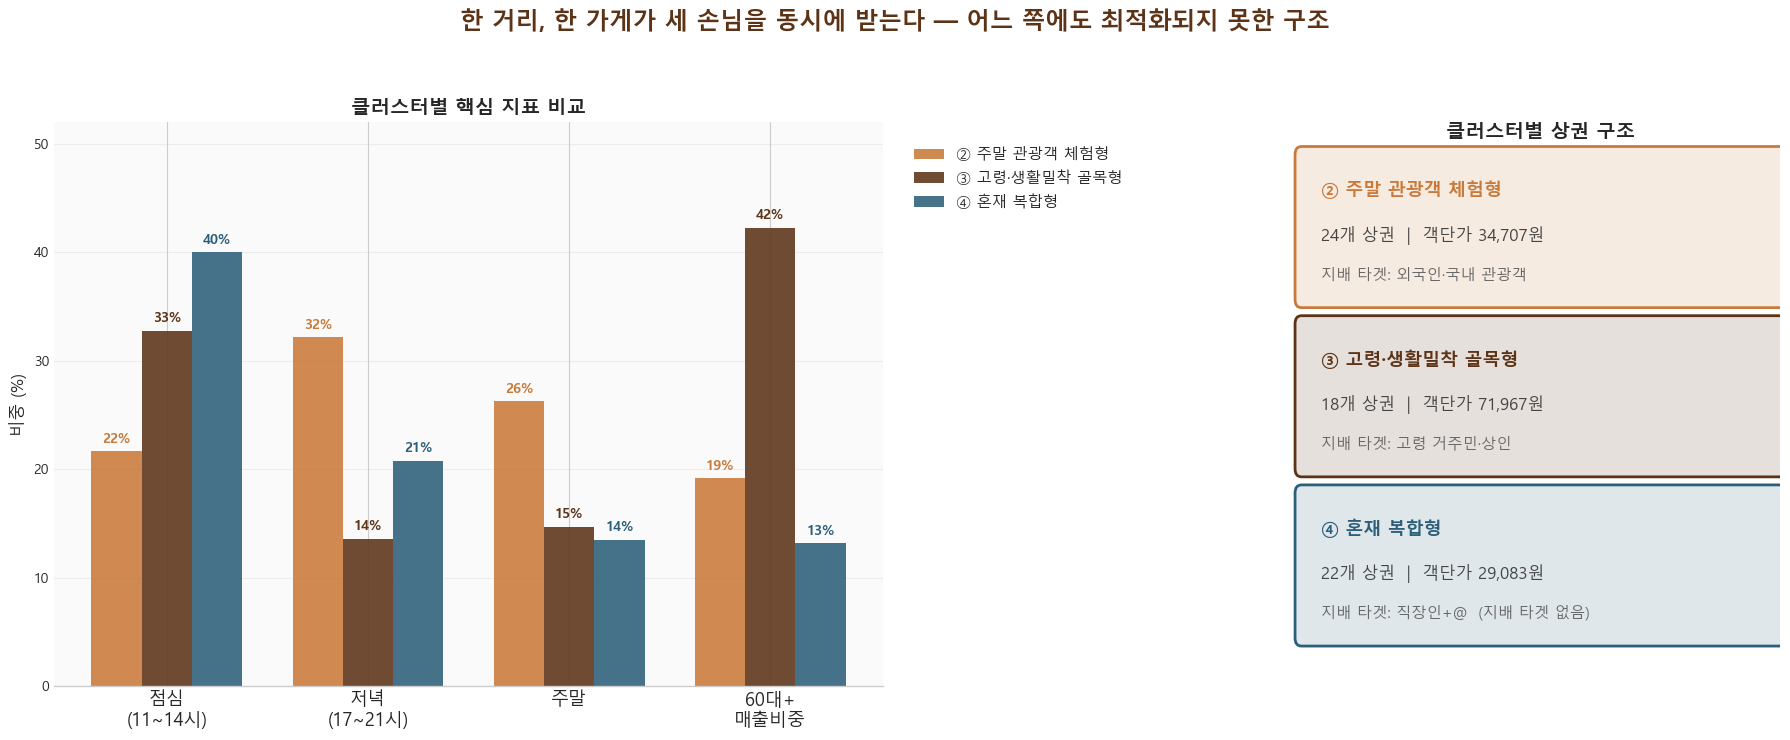

In [127]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

# 윈도우 한글 폰트 및 마이너스 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

cluster_data = {
    '② 주말\n관광객 체험형': {
        '상권수': 24, '점심비중': 21.7, '저녁비중': 32.2,
        '주말비중': 26.3, '60대+비중': 19.2, '객단가': 34707,
    },
    '③ 고령·생활밀착\n골목형': {
        '상권수': 18, '점심비중': 32.8, '저녁비중': 13.6,
        '주말비중': 14.7, '60대+비중': 42.3, '객단가': 71967,
    },
    '④ 혼재\n복합형': {
        '상권수': 22, '점심비중': 40.0, '저녁비중': 20.8,
        '주말비중': 13.5, '60대+비중': 13.2, '객단가': 29083,
    },
}

labels   = list(cluster_data.keys())
cols_cls = ['#c97a3a', '#5c3317', '#2c5f7a']
지표_목록 = ['점심비중', '저녁비중', '주말비중', '60대+비중']
지표_라벨 = ['점심\n(11~14시)', '저녁\n(17~21시)', '주말', '60대+\n매출비중']

# 왼쪽 차트 공간을 조금 더 확보
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.3, 1]})
fig.patch.set_facecolor('#FFFFFF')

# -------------------------------------------------------------
# 좌: 클러스터별 지표 그룹 막대
ax1 = axes[0]; ax1.set_facecolor('#FAFAFA')
x = np.arange(len(지표_목록)); w = 0.25

for i, (label, col) in enumerate(zip(labels, cols_cls)):
    vals = [cluster_data[label][k] for k in 지표_목록]
    bars = ax1.bar(x + (i - 1) * w, vals, width=w, color=col, alpha=0.88,
                   label=label.replace('\n', ' '))
    for bar in bars:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=10, color=col, fontweight='bold')

ax1.set_xticks(x); ax1.set_xticklabels(지표_라벨, fontsize=13)
ax1.set_ylabel('비중 (%)', fontsize=12)
ax1.set_title('클러스터별 핵심 지표 비교', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# [수정 1] Y축 최대치를 확 늘려서 막대가 천장에 안 닿게 함
ax1.set_ylim(0, 52) 
# [수정 2] 범례(설명)를 그래프 바깥쪽(오른쪽 옆 빈공간)으로 아예 빼버림
ax1.legend(fontsize=11, loc='upper left', bbox_to_anchor=(1.02, 0.98)) 


# -------------------------------------------------------------
# 우: 상권 수 + 객단가 요약 카드
ax2 = axes[1]; ax2.axis('off')
ax2.set_xlim(0, 10); ax2.set_ylim(0, 7)

card_info = [
    ('② 주말 관광객 체험형', '24개 상권', '객단가 34,707원', '외국인·국내 관광객', cols_cls[0]),
    ('③ 고령·생활밀착 골목형', '18개 상권', '객단가 71,967원', '고령 거주민·상인', cols_cls[1]),
    ('④ 혼재 복합형', '22개 상권', '객단가 29,083원', '직장인+@  (지배 타겟 없음)', cols_cls[2]),
]

# [수정 3] 범례가 들어갈 공간을 피해 박스들을 오른쪽 끝으로 더 밀어냄
box_x = 2.5
box_w = 7.5
text_x = box_x + 0.3

for i, (title, count, unit, target, col) in enumerate(card_info):
    y_top = 6.5 - i * 2.1
    ax2.add_patch(FancyBboxPatch((box_x, y_top - 1.7), box_w, 1.8,
                                  boxstyle='round,pad=0.1', facecolor=col,
                                  edgecolor='none', alpha=0.15))
    ax2.add_patch(FancyBboxPatch((box_x, y_top - 1.7), box_w, 1.8,
                                  boxstyle='round,pad=0.1', facecolor='none',
                                  edgecolor=col, linewidth=2))
    ax2.text(text_x, y_top - 0.35, title, fontsize=13, fontweight='bold', color=col, va='center')
    ax2.text(text_x, y_top - 0.9, f'{count}  |  {unit}', fontsize=12, color='#444', va='center')
    ax2.text(text_x, y_top - 1.4, f'지배 타겟: {target}', fontsize=11, color='#666', va='center', style='italic')
    
ax2.text(box_x + (box_w/2), 6.8, '클러스터별 상권 구조', fontsize=14, fontweight='bold', ha='center')

# -------------------------------------------------------------
fig.suptitle('한 거리, 한 가게가 세 손님을 동시에 받는다 — 어느 쪽에도 최적화되지 못한 구조',
             fontsize=17, fontweight='bold', color='#5c3317', y=1.05)
plt.tight_layout()
plt.show()

## [전략 도출] C유형(복합형) 종합 — EDA 발견 → 문제 진단 → 전략 방향

4가지 EDA 발견이 3개 전략으로 이어지는 논리 흐름을 한 장에 정리합니다.

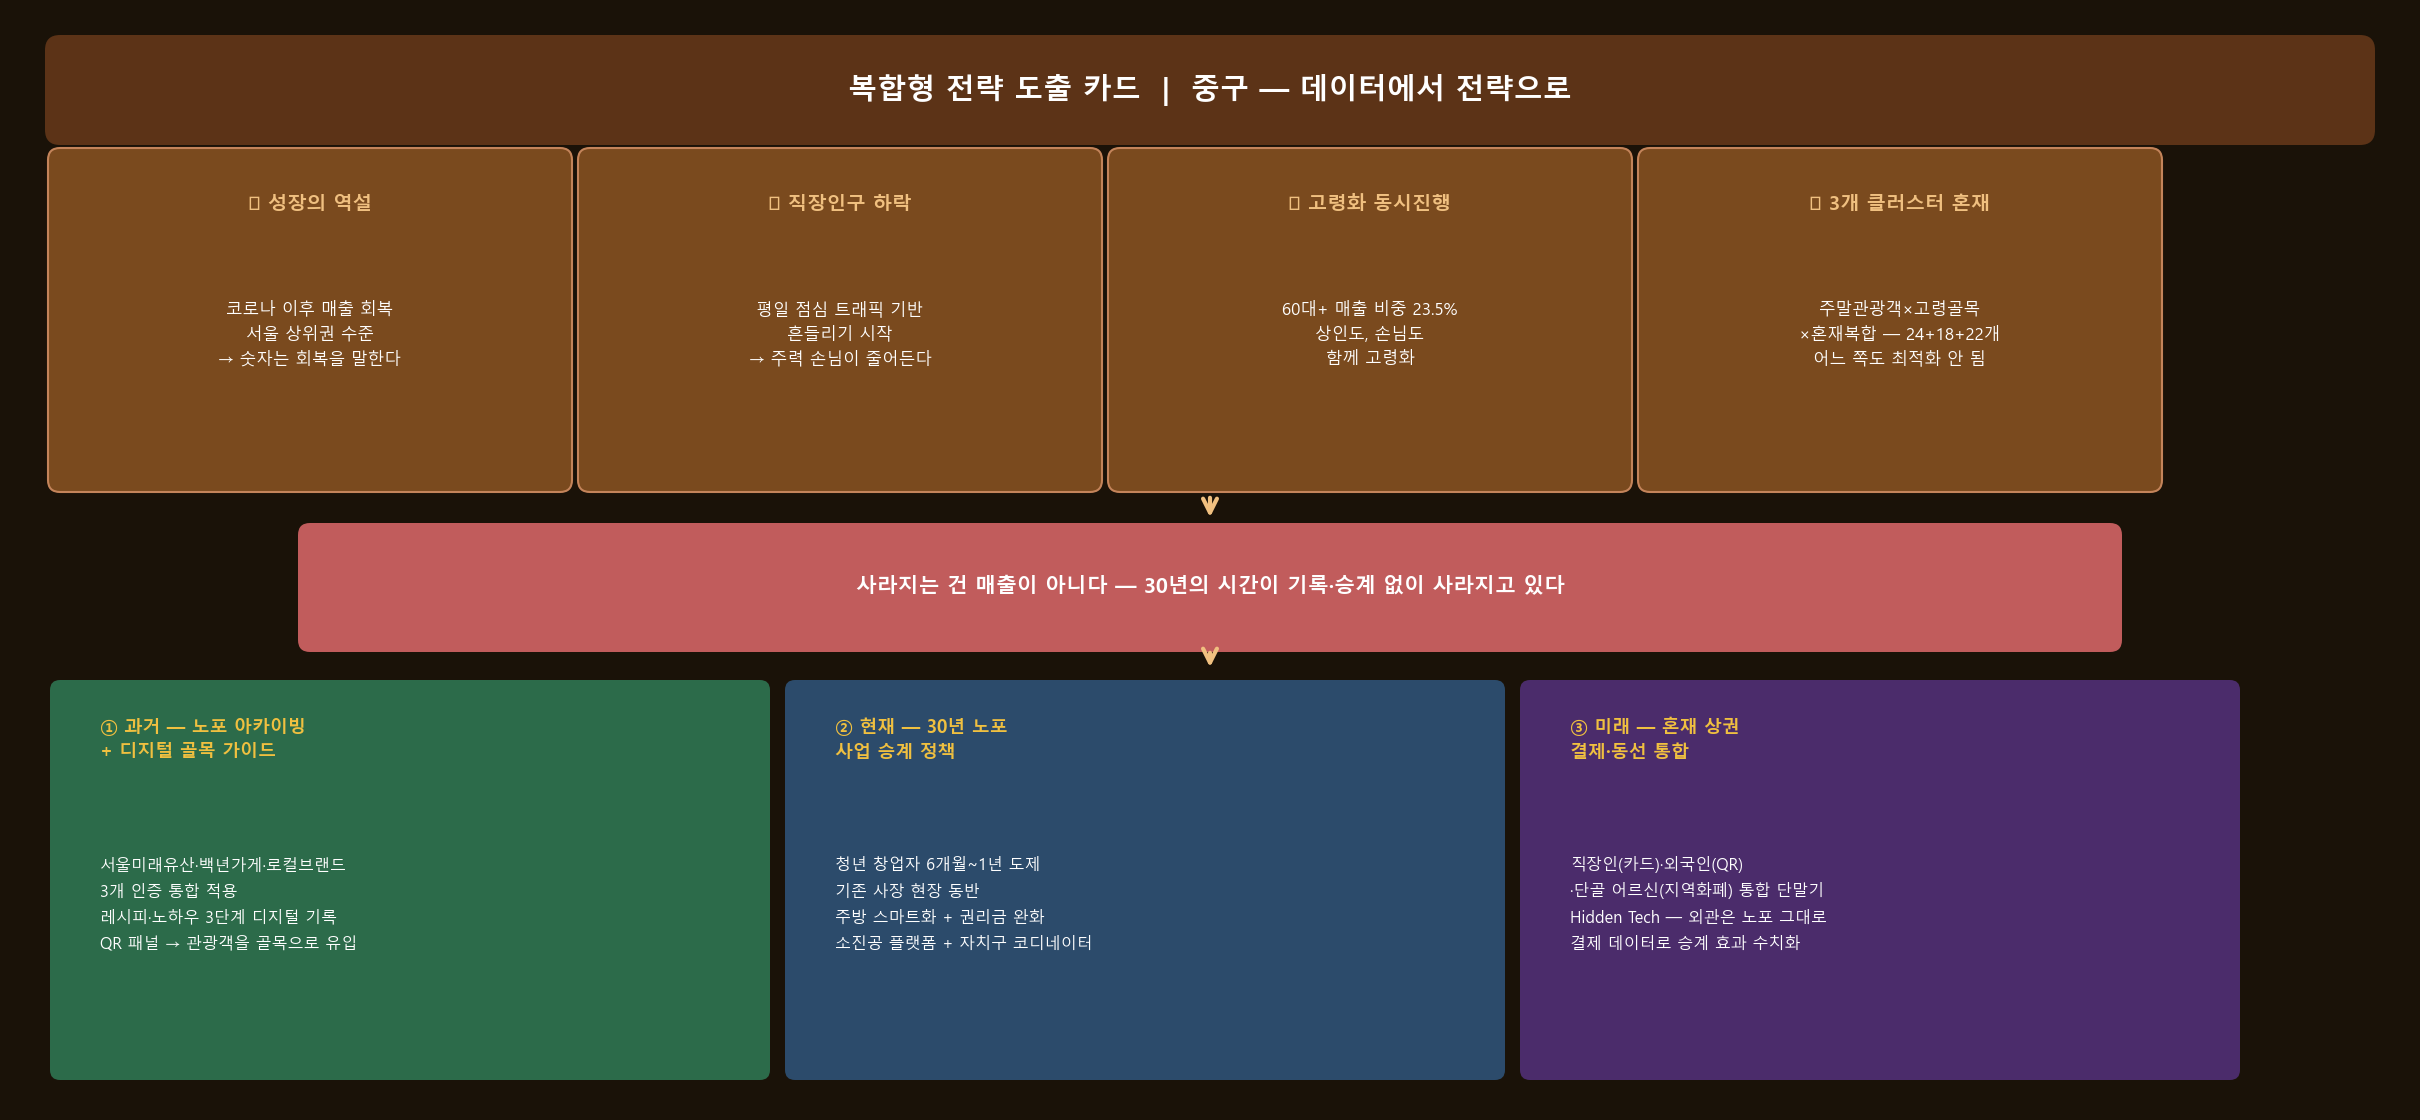

In [119]:
# ── [전략 도출] C유형(복합형) 종합 카드 ──

fig, ax = plt.subplots(figsize=(24, 11))
ax.set_xlim(0, 24); ax.set_ylim(0, 11); ax.axis('off')
fig.patch.set_facecolor('#1a1208'); ax.set_facecolor('#1a1208')

# 1. 타이틀 바
ax.add_patch(FancyBboxPatch((0.5, 9.8), 23.0, 0.8, boxstyle='round,pad=0.15',
                             facecolor='#5c3317', edgecolor='none'))
ax.text(12, 10.2, '복합형 전략 도출 카드  |  중구 — 데이터에서 전략으로',
        ha='center', va='center', fontsize=21, color='white', fontweight='bold')

# 2. 발견 박스 (4개)
발견_데이터 = [
    ('📈 성장의 역설',
     '코로나 이후 매출 회복\n서울 상위권 수준\n→ 숫자는 회복을 말한다'),
    ('📉 직장인구 하락',
     '평일 점심 트래픽 기반\n흔들리기 시작\n→ 주력 손님이 줄어든다'),
    ('👴 고령화 동시진행',
     '60대+ 매출 비중 23.5%\n상인도, 손님도\n함께 고령화'),
    ('🏪 3개 클러스터 혼재',
     '주말관광객×고령골목\n×혼재복합 — 24+18+22개\n어느 쪽도 최적화 안 됨'),
]

bw, bh = 5.0, 3.2
for i, (title, body) in enumerate(발견_데이터):
    bx = 0.5 + i * (bw + 0.3)
    by = 6.3
    ax.add_patch(FancyBboxPatch((bx, by), bw, bh, boxstyle='round,pad=0.12',
                                 facecolor='#7a4a1e', edgecolor='#c4845a', linewidth=1.5))
    ax.text(bx + bw/2, by + bh - 0.45, title,
            ha='center', va='center', fontsize=14, color='#f0c080', fontweight='bold')
    ax.text(bx + bw/2, by + bh/2 - 0.15, body,
            ha='center', va='center', fontsize=12, color='white',
            multialignment='center', linespacing=1.6)

# 화살표
ax.annotate('', xy=(12, 5.9), xytext=(12, 6.15),
            arrowprops=dict(arrowstyle='->', color='#f0c080', lw=3, mutation_scale=25))

# 3. 핵심 문제 박스
ax.add_patch(FancyBboxPatch((3.0, 4.7), 18.0, 1.05, boxstyle='round,pad=0.12',
                             facecolor='#c15c5c', edgecolor='none'))
ax.text(12, 5.22,
        '사라지는 건 매출이 아니다 — 30년의 시간이 기록·승계 없이 사라지고 있다',
        ha='center', va='center', fontsize=15, color='white', fontweight='bold')

# 화살표
ax.annotate('', xy=(12, 4.4), xytext=(12, 4.6),
            arrowprops=dict(arrowstyle='->', color='#f0c080', lw=3, mutation_scale=25))

# 4. 전략 박스 (3개)
전략_데이터 = [
    ('① 과거 — 노포 아카이빙\n+ 디지털 골목 가이드',
     '서울미래유산·백년가게·로컬브랜드\n3개 인증 통합 적용\n레시피·노하우 3단계 디지털 기록\nQR 패널 → 관광객을 골목으로 유입'),
    ('② 현재 — 30년 노포\n사업 승계 정책',
     '청년 창업자 6개월~1년 도제\n기존 사장 현장 동반\n주방 스마트화 + 권리금 완화\n소진공 플랫폼 + 자치구 코디네이터'),
    ('③ 미래 — 혼재 상권\n결제·동선 통합',
     '직장인(카드)·외국인(QR)\n·단골 어르신(지역화폐) 통합 단말기\nHidden Tech — 외관은 노포 그대로\n결제 데이터로 승계 효과 수치화'),
]

sw, sh = 7.0, 3.8
cols_s = ['#2c6b4a', '#2c4b6b', '#4b2c6b']
for i, (title, body) in enumerate(전략_데이터):
    sx = 0.5 + i * (sw + 0.35)
    sy_bottom = 0.4
    ax.add_patch(FancyBboxPatch((sx, sy_bottom), sw, sh, boxstyle='round,pad=0.1',
                                 facecolor=cols_s[i], edgecolor='none'))
    ax.text(sx + 0.4, sy_bottom + sh - 0.5, title,
            ha='left', va='center', fontsize=13,
            color='#f0c040', fontweight='bold', multialignment='left', linespacing=1.5)
    ax.text(sx + 0.4, sy_bottom + sh/2 - 0.25, body,
            ha='left', va='center', fontsize=11.5,
            color='white', multialignment='left', linespacing=1.7)

plt.tight_layout(pad=0)
plt.savefig('../data/output/스토리텔링_C유형_전략도출카드.png', dpi=150, bbox_inches='tight')
plt.show()